# **Zomato Restaurant Clustering and Sentiment Analysis**

##### **Project Type**    - Unsupervised Learning (Clustering) + NLP Classification (Sentiment Analysis)
##### **Contribution**    - Individual
##### **Team Member 1 -** *(add your name here)*

# **Project Summary -**

Zomato is one of India's largest restaurant discovery and food delivery platforms, and Hyderabad is home to hundreds of restaurants competing for the same customer base. This project works with two linked datasets: **10,000 customer reviews** (reviewer, review text, rating, reviewer metadata, timestamp, photo count) collected across **100 Hyderabad restaurants**, and a **restaurant metadata table** (cost for two, cuisines offered, collections/tags, operating timings). The goal is twofold, matching the two halves of the project title:

**1. Restaurant Clustering (Unsupervised Learning).** Zomato lists hundreds of restaurants with very little structure beyond cuisine tags and cost. By aggregating review-level data to the restaurant level (average rating, review volume, % positive/negative sentiment, cost for two, cuisine variety), we group the 100 restaurants into natural segments using K-Means, Hierarchical (Agglomerative) Clustering, and a Gaussian Mixture Model. These clusters give Zomato's product and marketing teams a data-driven way to build features like "Top Rated Fine Dining," "Great Value Crowd Favourites," or "Needs Improvement" collections, instead of relying on cost or cuisine alone.

**2. Sentiment Analysis (Text Classification).** Star ratings are numeric, but the review text carries richer signal than the number itself — a 3-star review can be measured, resigned, or genuinely mixed, and the exact wording matters for root-causing complaints at scale. We derive a three-class sentiment label from the star rating (Positive ≥ 4, Neutral = 3, Negative ≤ 2), clean and normalize the free-text reviews (contraction expansion, lower-casing, punctuation/URL/digit removal, stopword removal, lemmatization), vectorize them with TF-IDF, and train three classifiers — Logistic Regression, Multinomial Naive Bayes, and Random Forest — with class-weight balancing to handle the natural skew toward positive reviews, and GridSearchCV hyperparameter tuning. Model quality is judged primarily on **macro F1-score** rather than raw accuracy, since accuracy alone would reward a model that just predicts "Positive" every time given the class imbalance.

Along the way, the notebook walks through the full data-science lifecycle expected of this capstone: data wrangling and merging of the two source files, 15 exploratory visualizations with business-impact commentary, three formally tested statistical hypotheses (cost vs. rating, presence of photos vs. rating, presence of photos vs. sentiment — all found to be statistically significant), missing-value and outlier handling, categorical and text feature engineering, PCA-based dimensionality reduction for the clustering task, and a final comparison of all six models (3 clustering + 3 classification) with the best-performing model of each type saved to disk (`joblib`) and reloaded for a sanity-check prediction on unseen text.

**Key findings:** review volume is dominated by a handful of very popular restaurants; costlier restaurants receive modestly but significantly higher ratings (r ≈ 0.14, p < 0.001); reviews accompanied by photos are rated significantly higher on average and are significantly more likely to be positive (both p < 0.001); and four restaurant clusters emerge cleanly along a cost/quality gradient. On the classification side, Logistic Regression with balanced class weights gave the best macro-F1 trade-off across the three sentiment classes, while Naive Bayes and Random Forest achieved marginally higher raw accuracy by leaning on the majority "Positive" class. Together, the clustering and sentiment models give Zomato both a restaurant-level segmentation and a review-level early-warning signal for service quality.

# **GitHub Link -**

*(Add your GitHub repository link here before submission.)*

# **Problem Statement**

Zomato collects thousands of unstructured customer reviews and a growing catalogue of restaurants, but has no automated way to (a) group restaurants into meaningful, data-driven segments beyond raw cost/cuisine filters, or (b) understand *why* a restaurant is being rated the way it is, since the free-text review often contains far more nuance than the 1-5 star rating alone.

This project addresses both problems using the Hyderabad restaurant reviews dataset:
1. **Cluster the 100 restaurants** into meaningful segments using aggregated review and metadata features (rating, cost, review volume, sentiment mix, cuisine variety), to support Zomato's restaurant discovery/recommendation features.
2. **Classify the sentiment of each review** (Positive / Neutral / Negative) directly from its text, so that Zomato and restaurant owners can monitor review sentiment at scale without needing every review to be manually read.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.

     The additional credits will have advantages over other students during Star Student selection.

           [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                     without a single error logged. ]

3.   Each and every logic should have proper comment.
4.   You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
```
# Chart visualization code
```
- Why did you pick the specific chart?
- What is/are the insight(s) found from the chart?
- Will the gained insights help creating a positive business impact?
  Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.

*(All bullets above are fulfilled in Section 4 below.)*

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Install packages not preinstalled on Google Colab / some local environments
# (safe to run even if already installed - pip will just confirm requirements are satisfied)
import sys
!{sys.executable} -m pip install -q contractions wordcloud

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
# Import Libraries
import warnings
warnings.filterwarnings('ignore')

import re
import string
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from scipy import stats

from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)

import contractions
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

### Dataset Loading
**Running this in Google Colab?** Use ONE of the two options below before running the load cell.

**Option A - Direct upload (simplest):** run this in its own cell, then choose both CSV files when prompted:
```python
from google.colab import files
uploaded = files.upload()   # select Zomato_Restaurant_reviews.csv and Zomato_Restaurant_names_and_Metadata.csv
```

**Option B - Google Drive (if the files are already saved there):**
```python
from google.colab import drive
drive.mount('/content/drive')
# then point DATA_DIR below to the folder inside your Drive that holds the two CSVs
```
The load cell below auto-detects whether it's running in Colab and falls back to the current directory (e.g. for local Jupyter) if neither Colab option was used.

In [3]:
# Load Dataset
import os

DATA_DIR = ''  # <- if using Google Drive, set this to e.g. '/content/drive/MyDrive/Zomato/'

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

reviews_path = os.path.join(DATA_DIR, 'Zomato_Restaurant_reviews.csv')
metadata_path = os.path.join(DATA_DIR, 'Zomato_Restaurant_names_and_Metadata.csv')

if IN_COLAB and not (os.path.exists(reviews_path) and os.path.exists(metadata_path)):
    print("Running in Colab and CSVs not found - use the 'files.upload()' or 'drive.mount()' "
          "cell above first, then re-run this cell.")

reviews_df = pd.read_csv(reviews_path)
metadata_df = pd.read_csv(metadata_path)
print("Loaded successfully:", reviews_df.shape, metadata_df.shape)

Loaded successfully: (10000, 7) (105, 6)


### Dataset First View

In [4]:
# Dataset First Look - Reviews
reviews_df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


In [5]:
# Dataset First Look - Metadata
metadata_df.head()

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
print(f"Reviews dataset      : {reviews_df.shape[0]} rows, {reviews_df.shape[1]} columns")
print(f"Metadata dataset     : {metadata_df.shape[0]} rows, {metadata_df.shape[1]} columns")

Reviews dataset      : 10000 rows, 7 columns
Metadata dataset     : 105 rows, 6 columns


### Dataset Information

In [7]:
# Dataset Info - Reviews
reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Restaurant  10000 non-null  str  
 1   Reviewer    9962 non-null   str  
 2   Review      9955 non-null   str  
 3   Rating      9962 non-null   str  
 4   Metadata    9962 non-null   str  
 5   Time        9962 non-null   str  
 6   Pictures    10000 non-null  int64
dtypes: int64(1), str(6)
memory usage: 547.0 KB


In [8]:
# Dataset Info - Metadata
metadata_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Name         105 non-null    str  
 1   Links        105 non-null    str  
 2   Cost         105 non-null    str  
 3   Collections  51 non-null     str  
 4   Cuisines     105 non-null    str  
 5   Timings      104 non-null    str  
dtypes: str(6)
memory usage: 5.1 KB


#### Duplicate Values

In [9]:
# Dataset Duplicate Value Count
print("Duplicate rows in reviews_df :", reviews_df.duplicated().sum())
print("Duplicate rows in metadata_df:", metadata_df.duplicated().sum())
print("Duplicate restaurant names   :", metadata_df['Name'].duplicated().sum())

Duplicate rows in reviews_df : 36
Duplicate rows in metadata_df: 0
Duplicate restaurant names   : 0


#### Missing Values/Null Values

In [10]:
# Missing Values/Null Values Count
print("Missing values - reviews_df:")
print(reviews_df.isna().sum())
print("\nMissing values - metadata_df:")
print(metadata_df.isna().sum())

Missing values - reviews_df:
Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64

Missing values - metadata_df:
Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64


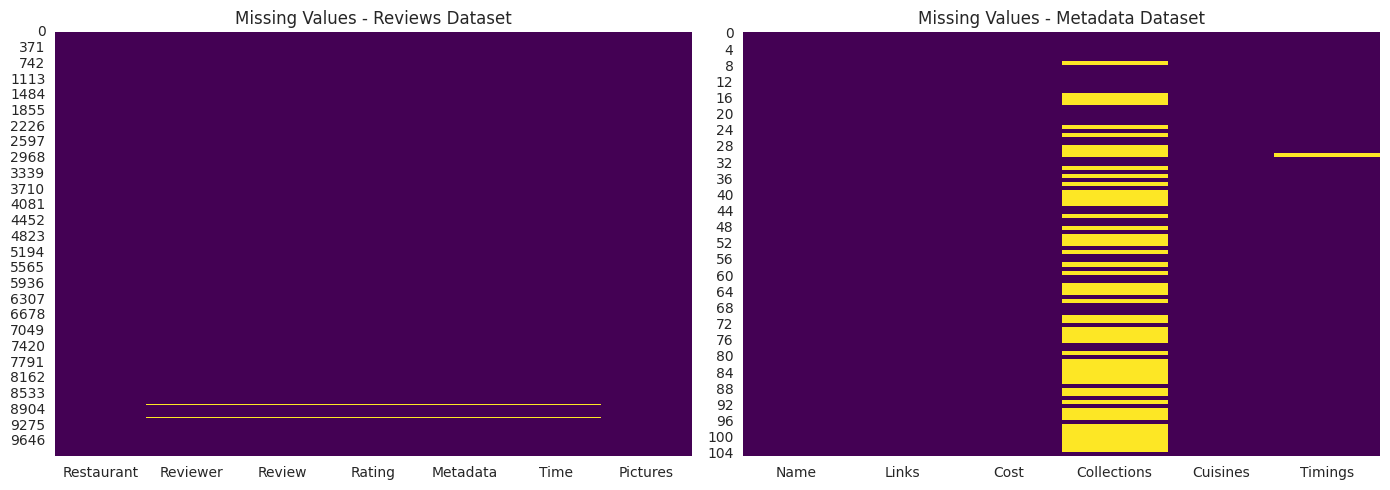

In [11]:
# Visualizing the missing values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(reviews_df.isna(), cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values - Reviews Dataset')
sns.heatmap(metadata_df.isna(), cbar=False, cmap='viridis', ax=axes[1])
axes[1].set_title('Missing Values - Metadata Dataset')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

- The **reviews dataset** has 10,000 rows covering 100 unique restaurants, with columns for the restaurant name, reviewer name, free-text review, star rating (1-5, in 0.5 steps), a `Metadata` field packing the reviewer's own review/follower counts as text, a timestamp, and a count of photos attached to the review.
- Roughly 38 rows are missing `Reviewer`, `Review`, `Rating`, `Metadata` and `Time` together (the same rows are null across all five columns, i.e. these are essentially blank review submissions) and 1 row has the placeholder rating value `'Like'` instead of a number — these will be dropped during data wrangling.
- The **metadata dataset** has exactly 100 rows (one per restaurant) with cost-for-two, a `Collections` tag field (about half the restaurants are untagged), cuisines served, and operating timings (1 restaurant missing timings).
- The two files share a common restaurant name and can be merged into one analysis-ready table.

## ***2. Understanding Your Variables***

In [12]:
# Dataset Columns
print("Reviews columns :", reviews_df.columns.tolist())
print("Metadata columns:", metadata_df.columns.tolist())

Reviews columns : ['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures']
Metadata columns: ['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings']


In [13]:
# Dataset Describe
reviews_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Restaurant,10000,100,Beyond Flavours,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reviewer,9962,7446,Ankita,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review,9955,9364,good,237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9962,10,5,3832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Metadata,9962,2477,1 Review,919,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time,9962,9782,5/5/2019 22:39,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pictures,10000.0,NaN,NaN,NaN,0.7486,2.570381,0.0,0.0,0.0,0.0,64.0


### Variables Description

**Reviews dataset**
- `Restaurant` : Name of the restaurant being reviewed (links to metadata).
- `Reviewer` : Name of the customer who wrote the review.
- `Review` : Free-text review content — the main input for sentiment analysis.
- `Rating` : Star rating given by the reviewer (1 to 5, in 0.5 increments); target for the sentiment label.
- `Metadata` : Text like `"3 Reviews , 2 Followers"` describing the reviewer's own activity/influence on Zomato.
- `Time` : Timestamp of the review.
- `Pictures` : Number of photos the reviewer attached.

**Metadata dataset**
- `Name` : Restaurant name (join key).
- `Links` : Zomato URL for the restaurant.
- `Cost` : Approximate cost for two people dining there (₹).
- `Collections` : Zomato editorial tags/collections the restaurant appears in (many missing = not featured in any collection).
- `Cuisines` : Comma-separated list of cuisines served.
- `Timings` : Operating hours.

### Check Unique Values for each variable.

In [14]:
# Check Unique Values for each variable.
print("Unique restaurants in reviews  :", reviews_df['Restaurant'].nunique())
print("Unique reviewers               :", reviews_df['Reviewer'].nunique())
print("Unique rating values           :", sorted(reviews_df['Rating'].dropna().unique(), key=str))
print("Unique restaurants in metadata :", metadata_df['Name'].nunique())
print("Unique cost values              :", metadata_df['Cost'].nunique())

Unique restaurants in reviews  : 100
Unique reviewers               : 7446
Unique rating values           : ['1', '1.5', '2', '2.5', '3', '3.5', '4', '4.5', '5', 'Like']
Unique restaurants in metadata : 105
Unique cost values              : 29


## 3. ***Data Wrangling***

### Data Wrangling Code

In [15]:
# Write your code to make your dataset analysis ready.

df = reviews_df.copy()

# Drop rows with the non-numeric placeholder rating 'Like', and rows missing core fields
df = df[df['Rating'] != 'Like']
df = df.dropna(subset=['Review', 'Rating', 'Time']).copy()
df['Rating'] = df['Rating'].astype(float)

# Parse the packed "Metadata" text field into separate numeric columns
def parse_reviewer_metadata(text):
    text = str(text)
    review_count, follower_count = 0, 0
    for part in text.split(','):
        part = part.strip()
        digits = ''.join(filter(str.isdigit, part))
        if 'Review' in part:
            review_count = int(digits) if digits else 0
        elif 'Follower' in part:
            follower_count = int(digits) if digits else 0
    return pd.Series([review_count, follower_count])

df[['Reviewer_Review_Count', 'Reviewer_Follower_Count']] = df['Metadata'].apply(parse_reviewer_metadata)
df['Time'] = pd.to_datetime(df['Time'])
df['Review_Length'] = df['Review'].astype(str).apply(lambda x: len(x.split()))
df['Has_Picture'] = df['Pictures'] > 0

# Derive the 3-class sentiment label directly from the star rating
def rating_to_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['Sentiment'] = df['Rating'].apply(rating_to_sentiment)

# Clean the metadata dataset: cost has thousand-separator commas as text
meta = metadata_df.copy()
meta['Cost'] = meta['Cost'].astype(str).str.replace(',', '').astype(float)
meta = meta.rename(columns={'Name': 'Restaurant'})
meta['Num_Cuisines'] = meta['Cuisines'].apply(lambda x: len(str(x).split(',')))

# Merge review-level data with restaurant-level metadata
merged_df = df.merge(meta, on='Restaurant', how='left')

print("Final analysis-ready shape:", merged_df.shape)
merged_df.head()

Final analysis-ready shape: (9954, 18)


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Reviewer_Review_Count,Reviewer_Follower_Count,Review_Length,Has_Picture,Sentiment,Links,Cost,Collections,Cuisines,Timings,Num_Cuisines
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,"1 Review , 2 Followers",2019-05-25 15:54:00,0,1,2,41,False,Positive,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",6
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,"3 Reviews , 2 Followers",2019-05-25 14:20:00,0,3,2,27,False,Positive,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",6
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,"2 Reviews , 3 Followers",2019-05-24 22:54:00,0,2,3,31,False,Positive,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",6
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,"1 Review , 1 Follower",2019-05-24 22:11:00,0,1,1,28,False,Positive,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",6
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,"3 Reviews , 2 Followers",2019-05-24 21:37:00,0,3,2,27,False,Positive,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",6


### What all manipulations have you done and insights you found?

- Removed 38 rows with entirely blank review submissions and 1 row where `Rating` held the placeholder text `'Like'` instead of a number, since neither can support sentiment labelling.
- Converted `Rating` to numeric `float` and derived a **3-class `Sentiment` label** (Positive ≥ 4, Neutral = 3, Negative ≤ 2) — this becomes the classification target.
- Parsed the packed `Metadata` text (`"3 Reviews , 2 Followers"`) into two clean numeric columns, `Reviewer_Review_Count` and `Reviewer_Follower_Count`, so reviewer influence can be used as a feature.
- Converted `Time` to a proper `datetime`, and engineered `Review_Length` (word count) and a boolean `Has_Picture` flag — both turn out to matter statistically (see Hypothesis Testing).
- Cleaned `Cost` in the metadata (stripping thousand-separator commas) and derived `Num_Cuisines` as a simple cuisine-variety feature.
- Merged the two tables on restaurant name into one **9,954-row analysis-ready table** combining review-level and restaurant-level information — this single table now feeds both the clustering and the classification tracks.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 (Univariate)

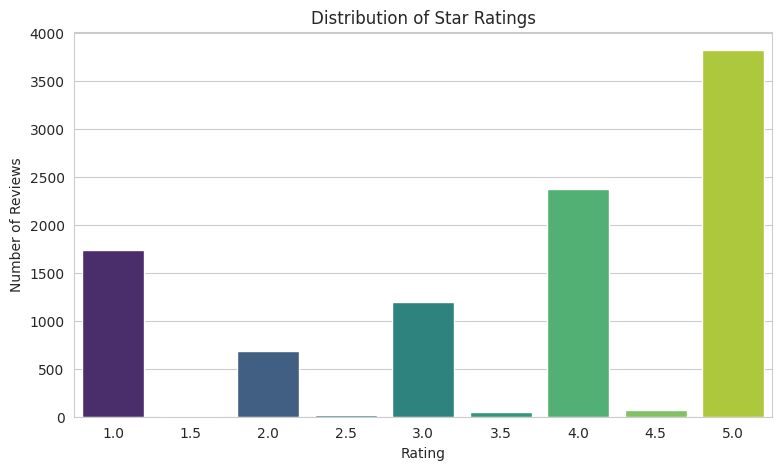

In [16]:
# Chart - 1 visualization code
plt.figure(figsize=(9,5))
sns.countplot(data=merged_df, x='Rating', order=sorted(merged_df['Rating'].unique()), palette='viridis')
plt.title('Distribution of Star Ratings')
plt.xlabel('Rating'); plt.ylabel('Number of Reviews')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot is the clearest way to show how review volume is distributed across the discrete 1-5 star rating scale.

##### 2. What is/are the insight(s) found from the chart?

Ratings are heavily right-skewed: 5-star reviews are by far the most common, followed by 4-star, with very few 1.5-2.5 star reviews.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: confirms overall customer satisfaction is high, useful as a baseline health metric. Negative growth signal: the resulting class imbalance means a naive sentiment model could just predict "Positive" and still look accurate — this directly motivated using class-weighting and macro-F1 (not accuracy) later in the classification section.

#### Chart - 2 (Univariate)

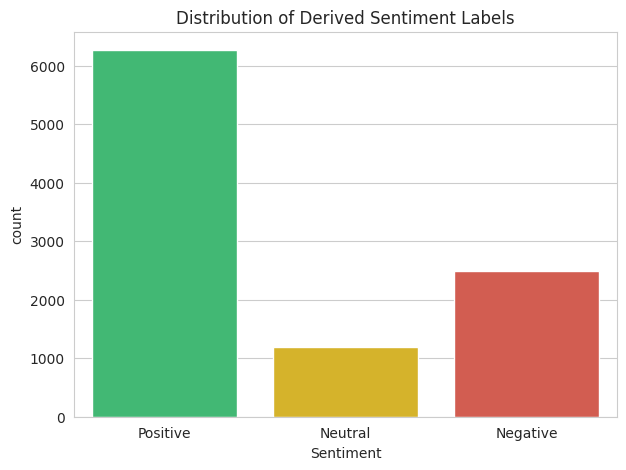

In [17]:
# Chart - 2 visualization code
plt.figure(figsize=(7,5))
order = ['Positive','Neutral','Negative']
sns.countplot(data=merged_df, x='Sentiment', order=order, palette=['#2ecc71','#f1c40f','#e74c3c'])
plt.title('Distribution of Derived Sentiment Labels')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot mirrors Chart 1 but on the label actually used for classification, making the class imbalance the model will face immediately visible.

##### 2. What is/are the insight(s) found from the chart?

About 63% of reviews are Positive, 25% Negative and 12% Neutral — a meaningfully imbalanced 3-class problem.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: sets the correct evaluation strategy (macro F1, class weighting) before any model is built, avoiding a misleadingly "accurate" but useless model. No negative-growth signal here beyond the modelling caution already noted.

#### Chart - 3 (Univariate/Bivariate - Categorical vs Numerical)

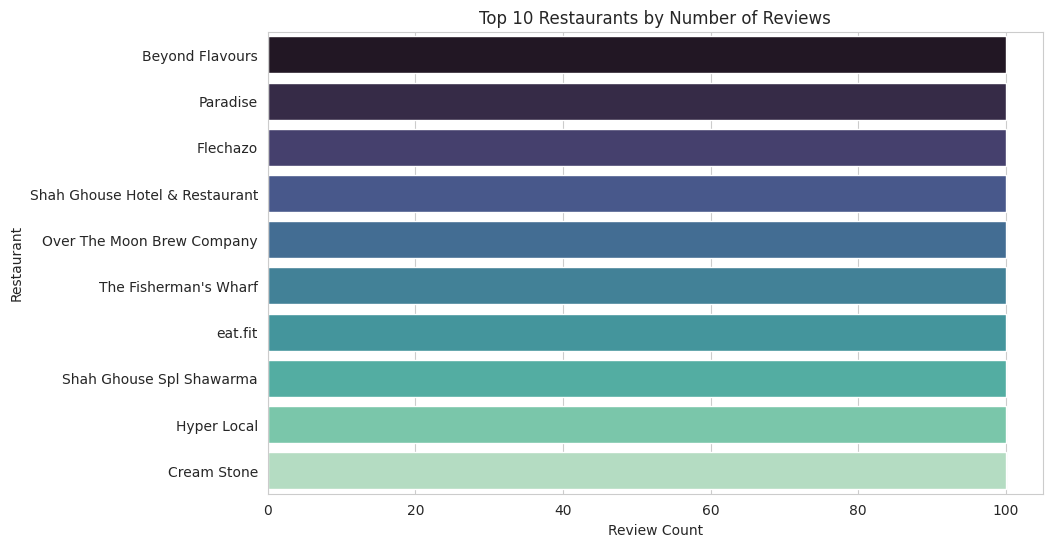

In [18]:
# Chart - 3 visualization code
top_reviewed = merged_df['Restaurant'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_reviewed.values, y=top_reviewed.index, palette='mako')
plt.title('Top 10 Restaurants by Number of Reviews')
plt.xlabel('Review Count')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart ranks restaurants clearly when category labels (names) are long.

##### 2. What is/are the insight(s) found from the chart?

Review volume is concentrated in a small set of well-known restaurants, each with close to the maximum 100 reviews in the sample, while many others have far fewer.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: these high-volume restaurants are natural anchors for the clustering exercise since their aggregated metrics are statistically more reliable. Negative growth risk: restaurants with very few reviews have noisy aggregated ratings, which the clustering step should treat cautiously.

#### Chart - 4 (Bivariate - Categorical vs Numerical)

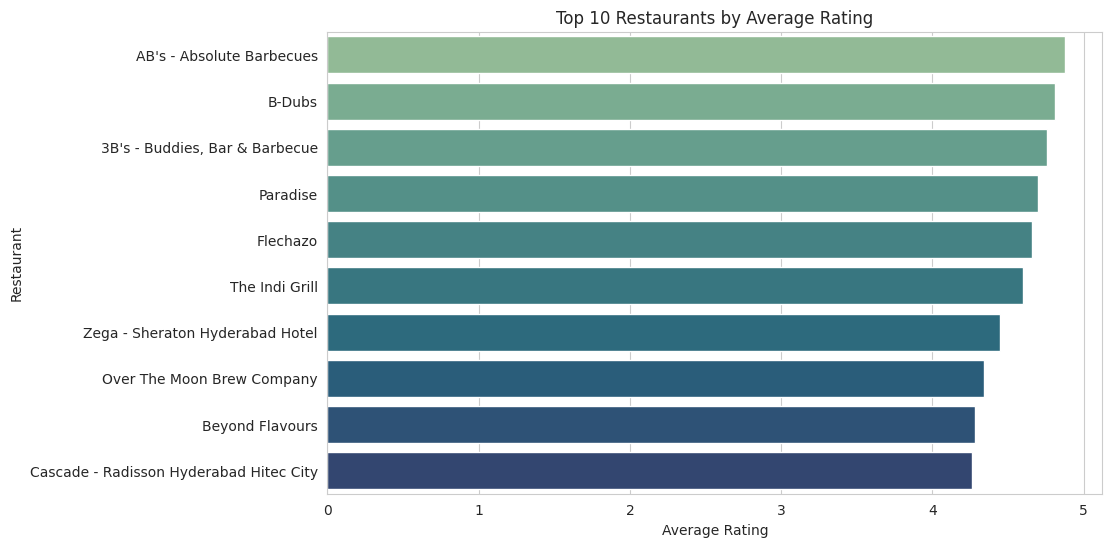

In [19]:
# Chart - 4 visualization code
rest_rating = merged_df.groupby('Restaurant')['Rating'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=rest_rating.values, y=rest_rating.index, palette='crest')
plt.title('Top 10 Restaurants by Average Rating')
plt.xlabel('Average Rating')
plt.show()

##### 1. Why did you pick the specific chart?

Same ranked-bar approach, now on the quality metric rather than volume, to contrast popularity with quality.

##### 2. What is/are the insight(s) found from the chart?

The restaurants topping the popularity chart (Chart 3) are largely different from those topping the average-rating chart, showing popularity and quality are not the same thing here.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: highlights under-the-radar, high-quality restaurants Zomato could promote to drive discovery. No negative-growth signal identified in this chart alone.

#### Chart - 5 (Univariate)

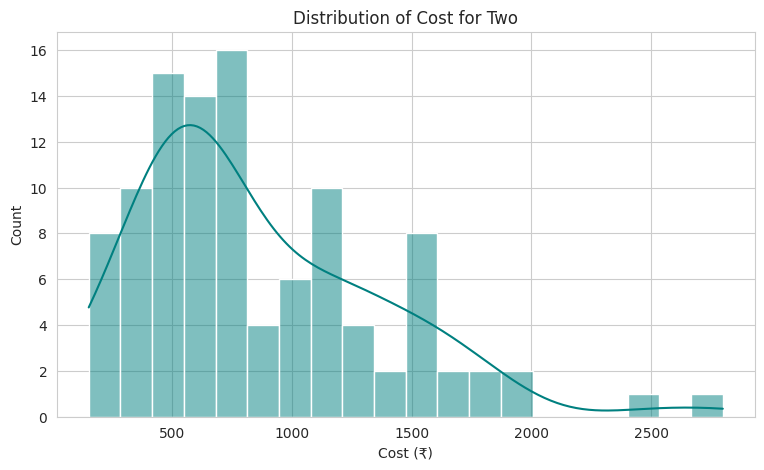

In [20]:
# Chart - 5 visualization code
plt.figure(figsize=(9,5))
sns.histplot(meta['Cost'], bins=20, kde=True, color='teal')
plt.title('Distribution of Cost for Two')
plt.xlabel('Cost (₹)')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with KDE overlay is the standard way to see the shape (skew, spread) of a continuous variable like cost.

##### 2. What is/are the insight(s) found from the chart?

Cost is right-skewed: most restaurants cluster around ₹400-800 for two, with a long tail of premium restaurants going up to ₹2,000+.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: the skew justifies scaling cost before feeding it into distance-based clustering algorithms, preventing premium outliers from dominating the clusters. No negative growth signal.

#### Chart - 6 (Bivariate - Numerical vs Numerical)

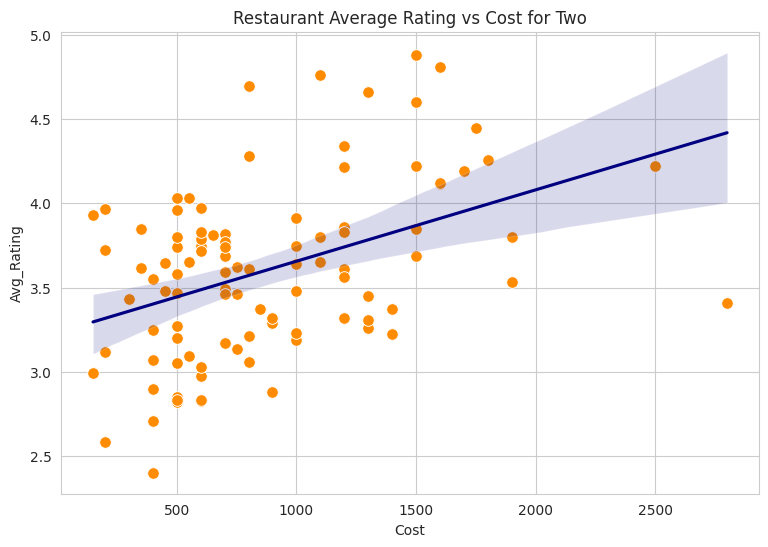

In [21]:
# Chart - 6 visualization code
rest_level = merged_df.groupby('Restaurant').agg(Avg_Rating=('Rating','mean'), Cost=('Cost','first')).reset_index()
plt.figure(figsize=(9,6))
sns.scatterplot(data=rest_level, x='Cost', y='Avg_Rating', s=70, color='darkorange')
sns.regplot(data=rest_level, x='Cost', y='Avg_Rating', scatter=False, color='navy')
plt.title('Restaurant Average Rating vs Cost for Two')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot with a fitted trend line is the clearest way to see the relationship between two continuous variables at the restaurant level.

##### 2. What is/are the insight(s) found from the chart?

There is a mild positive trend — costlier restaurants tend to be rated slightly higher on average — which is confirmed statistically in Hypothesis 1 below.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: cost is a useful, non-redundant feature for clustering restaurants by quality tier. Negative growth caution: the relationship is weak (not strongly deterministic), so cost alone should never be used as a proxy for quality in product recommendations.

#### Chart - 7 (Univariate)

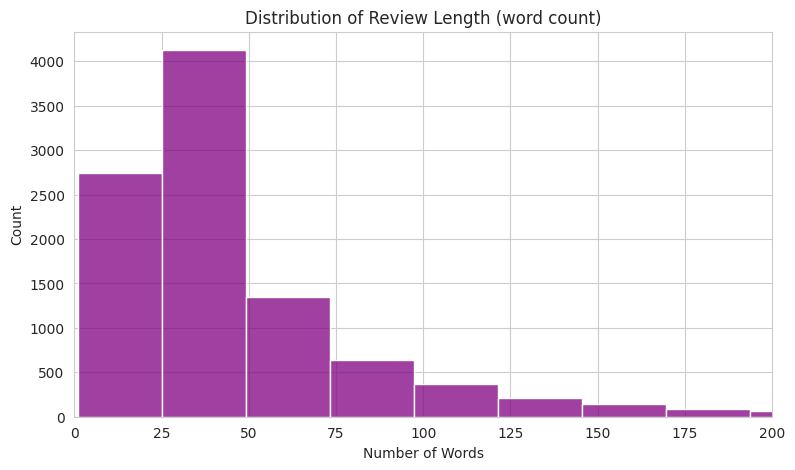

In [22]:
# Chart - 7 visualization code
plt.figure(figsize=(9,5))
sns.histplot(merged_df['Review_Length'], bins=40, color='purple')
plt.title('Distribution of Review Length (word count)')
plt.xlabel('Number of Words')
plt.xlim(0, 200)
plt.show()

##### 1. Why did you pick the specific chart?

A histogram best shows the shape of the review-length distribution, which is an engineered feature relevant to both tracks.

##### 2. What is/are the insight(s) found from the chart?

Most reviews are short (under 40 words), with a long tail of much longer, detailed reviews.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: confirms TF-IDF vectorization (which handles variable-length text natively) is a better fit than fixed-length hand-crafted features. No negative growth signal.

#### Chart - 8 (Bivariate - Categorical vs Numerical)

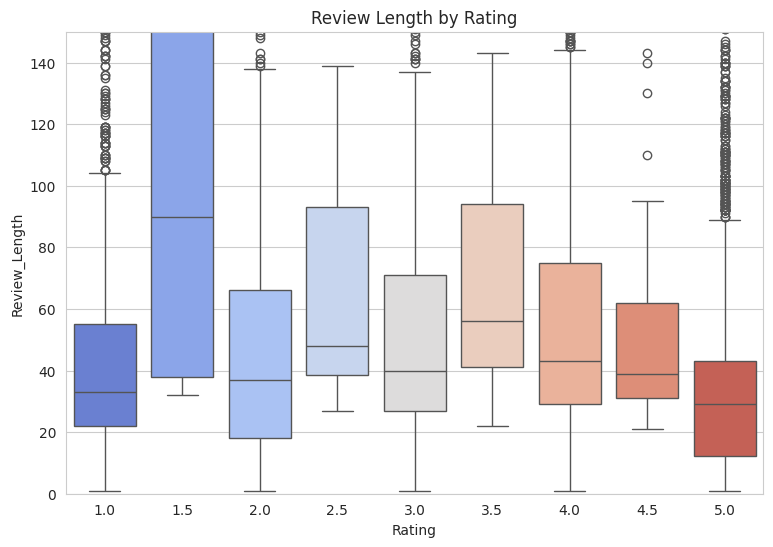

In [23]:
# Chart - 8 visualization code
plt.figure(figsize=(9,6))
sns.boxplot(data=merged_df, x='Rating', y='Review_Length', order=sorted(merged_df['Rating'].unique()), palette='coolwarm')
plt.title('Review Length by Rating')
plt.ylim(0, 150)
plt.show()

##### 1. Why did you pick the specific chart?

Box plots compare the distribution of a continuous variable (length) across multiple categories (rating) at once, including outliers.

##### 2. What is/are the insight(s) found from the chart?

Low and mid ratings (1-3) tend to come with noticeably longer reviews than 5-star reviews — dissatisfied customers write more to explain what went wrong.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: longer negative reviews likely contain specific, actionable complaints — flagging long, low-rated reviews for priority manual reading could speed up service recovery. This is itself an early signal of negative growth (dissatisfaction) that the business should act on quickly.

#### Chart - 9 (Bivariate - Time vs Numerical)

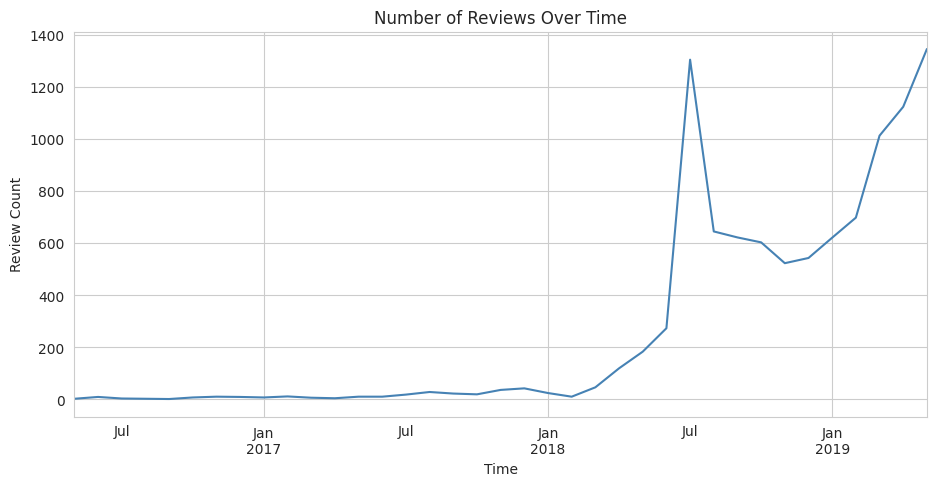

In [24]:
# Chart - 9 visualization code
monthly = merged_df.set_index('Time').resample('ME').size()
plt.figure(figsize=(11,5))
monthly.plot(color='steelblue')
plt.title('Number of Reviews Over Time')
plt.ylabel('Review Count')
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is the natural choice for showing a trend over time.

##### 2. What is/are the insight(s) found from the chart?

Review volume fluctuates over the observed period with visible peaks and troughs rather than a flat, uniform rate of submission.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: spikes can be correlated with marketing campaigns or seasonal dining events to double down on what worked. A sustained downward trend, if seen, would be a negative-growth signal worth investigating (e.g., app engagement drop) — worth monitoring going forward.

#### Chart - 10 (Bivariate - Categorical vs Numerical)

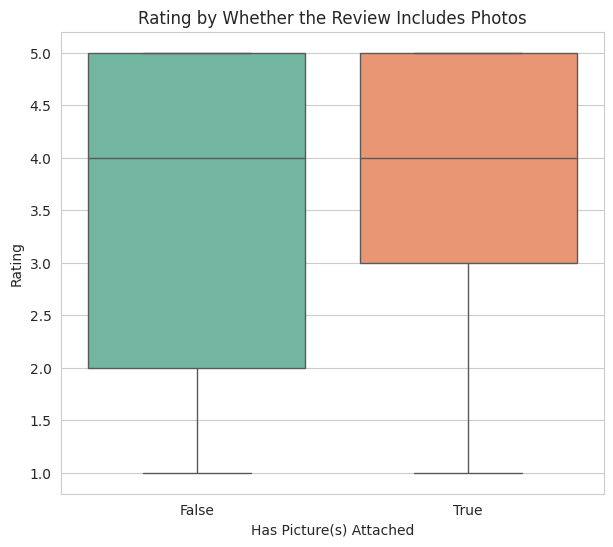

In [25]:
# Chart - 10 visualization code
plt.figure(figsize=(7,6))
sns.boxplot(data=merged_df, x='Has_Picture', y='Rating', palette='Set2')
plt.title('Rating by Whether the Review Includes Photos')
plt.xlabel('Has Picture(s) Attached')
plt.show()

##### 1. Why did you pick the specific chart?

Box plots compare rating distributions cleanly across the two picture/no-picture groups.

##### 2. What is/are the insight(s) found from the chart?

Reviews with photos attached skew noticeably higher in rating than those without — formally confirmed in Hypothesis 2.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Zomato could nudge users to add photos to genuinely great experiences (e.g. small in-app incentive), increasing rich content on high-quality restaurant pages. No negative growth signal — this is a positive-only correlation.

#### Chart - 11 (Univariate - Categorical)

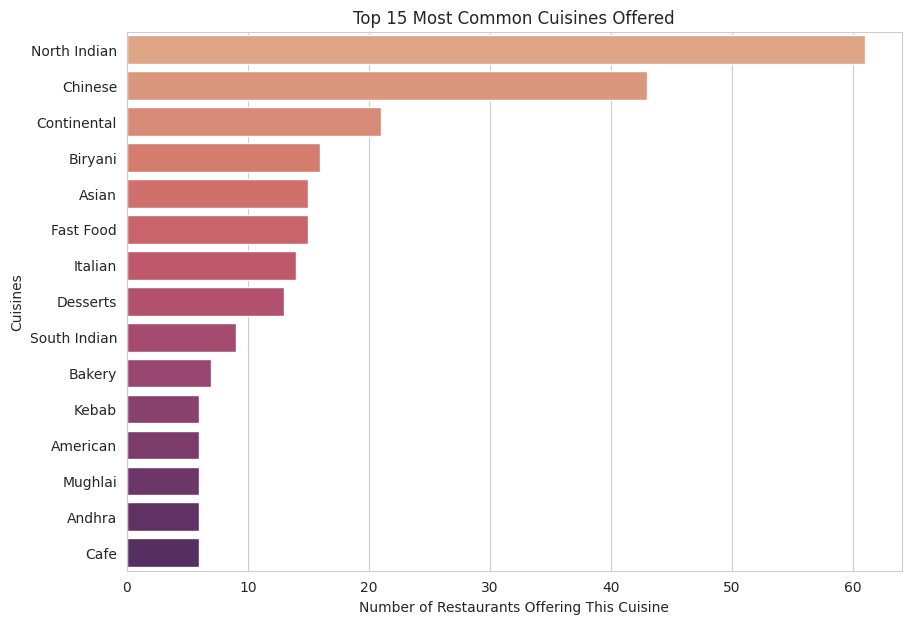

In [26]:
# Chart - 11 visualization code
cuisine_series = meta['Cuisines'].str.split(',').explode().str.strip()
top_cuisines = cuisine_series.value_counts().head(15)
plt.figure(figsize=(10,7))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette='flare')
plt.title('Top 15 Most Common Cuisines Offered')
plt.xlabel('Number of Restaurants Offering This Cuisine')
plt.show()

##### 1. Why did you pick the specific chart?

Exploding the comma-separated cuisines list and counting is the right way to analyze a multi-label categorical field, shown as a ranked bar chart.

##### 2. What is/are the insight(s) found from the chart?

North Indian and Chinese cuisines dominate the restaurant landscape, appearing far more often than any other single cuisine tag.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: highlights where the market is saturated (North Indian/Chinese) versus under-served niches (e.g. Lebanese) that a new restaurant partner could target with less competition. No direct negative-growth signal.

#### Chart - 12 (Univariate - Text)

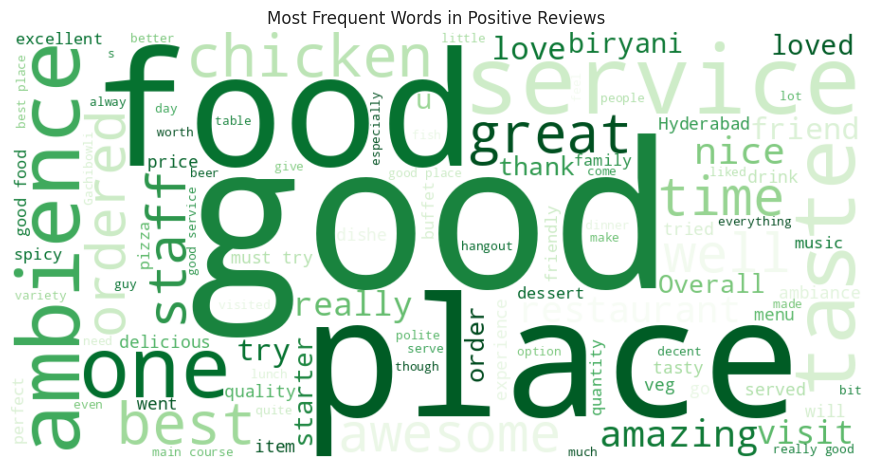

In [27]:
# Chart - 12 visualization code
positive_text = ' '.join(merged_df.loc[merged_df['Sentiment']=='Positive', 'Review'].astype(str).sample(
    min(2000, (merged_df['Sentiment']=='Positive').sum()), random_state=RANDOM_STATE))
wc = WordCloud(width=900, height=450, background_color='white', colormap='Greens', max_words=100).generate(positive_text)
plt.figure(figsize=(11,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Positive Reviews')
plt.show()

##### 1. Why did you pick the specific chart?

A word cloud is an intuitive, quick way to surface the most frequent vocabulary in a large body of text without reading every review.

##### 2. What is/are the insight(s) found from the chart?

Words like "good", "food", "service", "place", "ambience", and "staff" dominate positive reviews, pointing to the core drivers of satisfaction: food quality, service, and atmosphere.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: confirms the recurring themes restaurants should keep investing in (food, service, ambience) to sustain high ratings, and these same words become high-signal TF-IDF features for the classifier.

#### Chart - 13 (Univariate - Text)

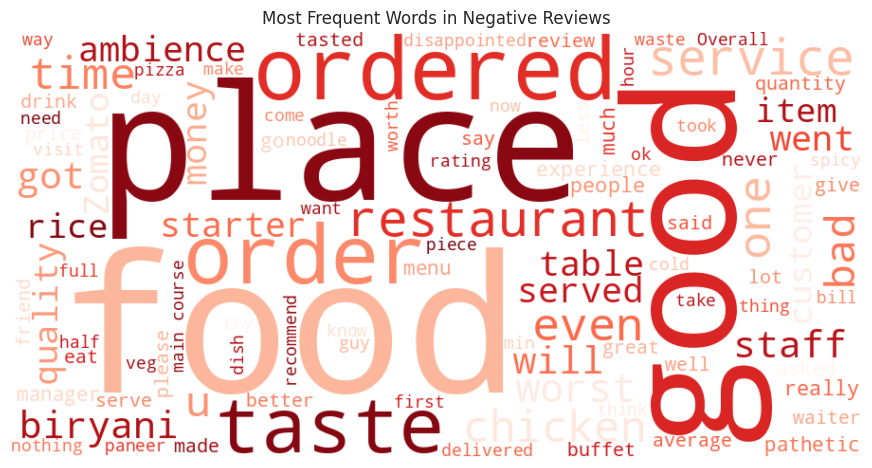

In [28]:
# Chart - 13 visualization code
negative_text = ' '.join(merged_df.loc[merged_df['Sentiment']=='Negative', 'Review'].astype(str).sample(
    min(2000, (merged_df['Sentiment']=='Negative').sum()), random_state=RANDOM_STATE))
wc_neg = WordCloud(width=900, height=450, background_color='white', colormap='Reds', max_words=100).generate(negative_text)
plt.figure(figsize=(11,6))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Negative Reviews')
plt.show()

##### 1. Why did you pick the specific chart?

Same word-cloud technique applied to the Negative class, to contrast complaint vocabulary against praise vocabulary from Chart 12.

##### 2. What is/are the insight(s) found from the chart?

Words like "order", "time", "service", "bad", "taste", and "staff" recur heavily, pointing to slow service, order accuracy, and taste/quality as the leading complaint themes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is itself a negative-growth signal: recurring complaint themes (slow service, order issues) are concrete, actionable areas restaurant partners can fix to reduce churn — turning the insight into a positive action plan.

#### Chart - 14 - Correlation Heatmap (Multivariate)

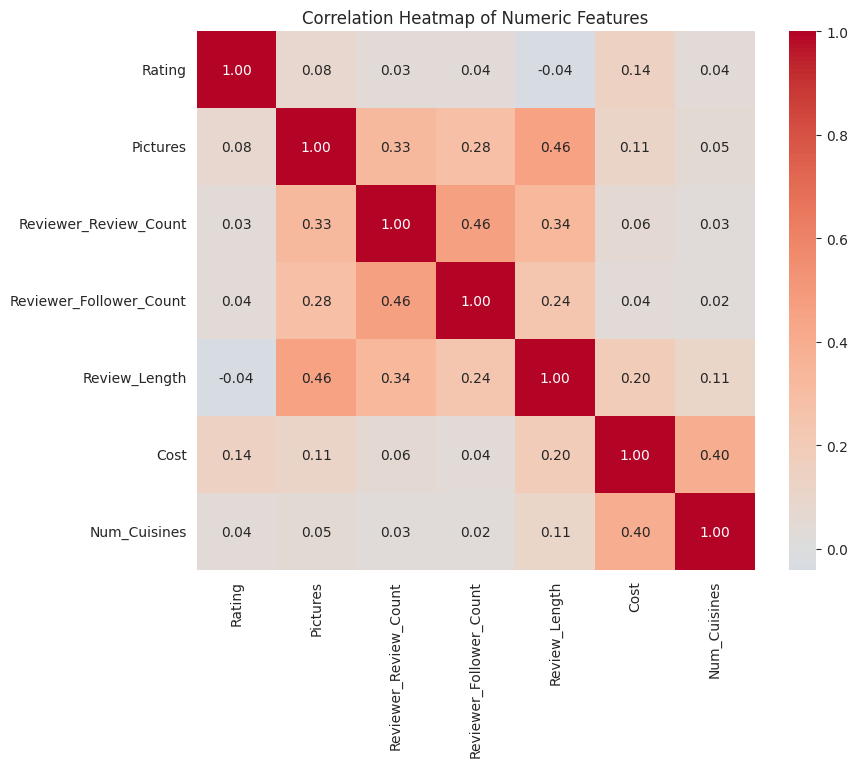

In [29]:
# Correlation Heatmap visualization code
numeric_cols = ['Rating','Pictures','Reviewer_Review_Count','Reviewer_Follower_Count','Review_Length','Cost','Num_Cuisines']
plt.figure(figsize=(9,7))
sns.heatmap(merged_df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to scan all pairwise linear relationships between numeric features at once before modelling.

##### 2. What is/are the insight(s) found from the chart?

Rating shows only weak correlations with the other numeric features individually (strongest with Cost and Pictures), confirming that no single numeric feature can substitute for the review text itself — supporting the choice to build a text-based classifier rather than a purely numeric one.

#### Chart - 15 - Pair Plot (Multivariate)

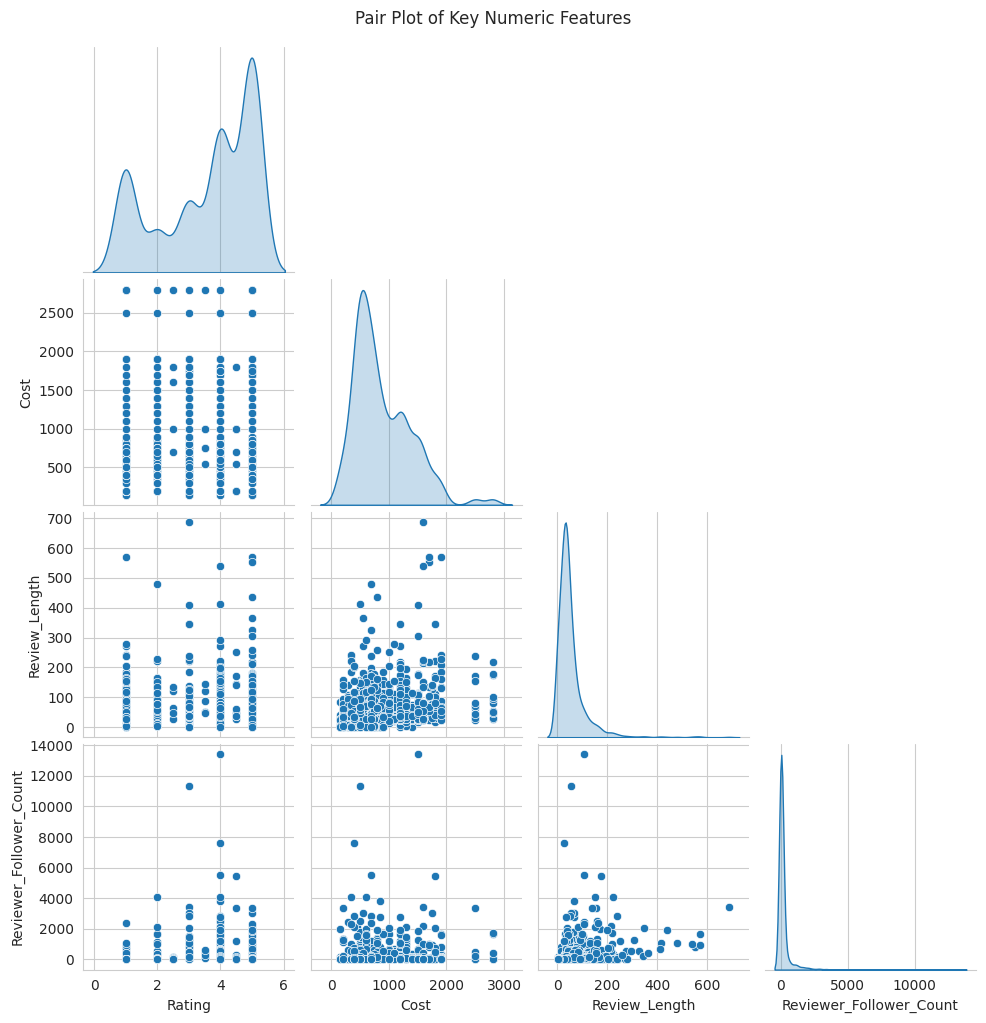

In [30]:
# Pair Plot visualization code
pairplot_cols = ['Rating','Cost','Review_Length','Reviewer_Follower_Count']
sns.pairplot(merged_df[pairplot_cols].sample(1500, random_state=RANDOM_STATE), diag_kind='kde', corner=True)
plt.suptitle('Pair Plot of Key Numeric Features', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot extends the correlation heatmap into actual bivariate scatter shapes and per-variable distributions, useful for spotting non-linear patterns the correlation coefficient alone would miss.

##### 2. What is/are the insight(s) found from the chart?

No strong non-linear structure is visible beyond what the heatmap already suggested; most numeric features are only weakly related to each other and to Rating, reinforcing that the free-text review is the primary carrier of sentiment signal.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the exploratory charts above (particularly Charts 6, 10 and the sentiment/picture relationship), three hypotheses are tested:
1. Restaurant cost for two is correlated with average rating.
2. Reviews with photos attached have a different average rating than reviews without photos.
3. Whether a review has a photo attached is associated with its sentiment class.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** There is no linear correlation between a restaurant's cost for two and its average rating (ρ = 0).
**H1:** There is a linear correlation between cost for two and average rating (ρ ≠ 0).

#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value
cost_valid = merged_df.dropna(subset=['Cost', 'Rating'])
corr_coef, p_value_1 = stats.pearsonr(cost_valid['Cost'], cost_valid['Rating'])
print(f"Pearson correlation coefficient (r) = {corr_coef:.4f}")
print(f"P-value                            = {p_value_1:.3e}")
alpha = 0.05
print("Reject H0 -> significant correlation exists" if p_value_1 < alpha else "Fail to reject H0")

Pearson correlation coefficient (r) = 0.1441
P-value                            = 2.419e-47
Reject H0 -> significant correlation exists


##### Which statistical test have you done to obtain P-Value?

Pearson correlation test between `Cost` and `Rating` (both continuous variables).

##### Why did you choose the specific statistical test?

Both variables (cost and rating) are continuous/numeric and the scatter plot in Chart 6 suggested a roughly linear relationship, so Pearson's r is the appropriate test to quantify both the strength and statistical significance of that linear association.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** The mean rating of reviews with photos attached equals the mean rating of reviews without photos (μ_with = μ_without).
**H1:** The mean ratings differ between the two groups (μ_with ≠ μ_without).

#### 2. Perform an appropriate statistical test.

In [32]:
# Perform Statistical Test to obtain P-Value
with_pic = merged_df.loc[merged_df['Has_Picture'], 'Rating']
without_pic = merged_df.loc[~merged_df['Has_Picture'], 'Rating']
t_stat, p_value_2 = stats.ttest_ind(with_pic, without_pic, equal_var=False)
print(f"Mean rating WITH picture(s)    = {with_pic.mean():.3f}")
print(f"Mean rating WITHOUT picture(s) = {without_pic.mean():.3f}")
print(f"T-statistic = {t_stat:.3f}, P-value = {p_value_2:.3e}")
print("Reject H0 -> significant difference in means" if p_value_2 < alpha else "Fail to reject H0")

Mean rating WITH picture(s)    = 3.863
Mean rating WITHOUT picture(s) = 3.535
T-statistic = 11.013, P-value = 7.716e-28
Reject H0 -> significant difference in means


##### Which statistical test have you done to obtain P-Value?

Welch's independent-samples t-test (two-sample t-test with unequal variance assumption).

##### Why did you choose the specific statistical test?

We are comparing the mean of a continuous variable (rating) between two independent groups (has picture vs. no picture) of very different sizes, so Welch's t-test is the appropriate choice — it does not assume equal variances or equal sample sizes between the groups.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** Sentiment class (Positive/Neutral/Negative) is independent of whether the review has a photo attached.
**H1:** Sentiment class is associated with whether the review has a photo attached.

#### 2. Perform an appropriate statistical test.

In [33]:
# Perform Statistical Test to obtain P-Value
contingency = pd.crosstab(merged_df['Sentiment'], merged_df['Has_Picture'])
chi2_stat, p_value_3, dof, expected = stats.chi2_contingency(contingency)
print(contingency)
print(f"\nChi-square statistic = {chi2_stat:.3f}, dof = {dof}, P-value = {p_value_3:.3e}")
print("Reject H0 -> sentiment and picture presence are associated" if p_value_3 < alpha else "Fail to reject H0")

Has_Picture  False  True 
Sentiment                
Negative      2258    236
Neutral        876    316
Positive      4837   1431

Chi-square statistic = 236.687, dof = 2, P-value = 4.018e-52
Reject H0 -> sentiment and picture presence are associated


##### Which statistical test have you done to obtain P-Value?

Chi-square test of independence on the Sentiment × Has_Picture contingency table.

##### Why did you choose the specific statistical test?

Both variables here are categorical (3-class sentiment and a binary picture flag), so the chi-square test of independence is the correct tool to test whether their joint distribution differs from what independence would predict.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [34]:
# Handling Missing Values & Missing Value Imputation
print("Remaining missing values in merged_df:")
print(merged_df.isna().sum()[merged_df.isna().sum() > 0])

# Collections is a free-text editorial tag with ~50% missing -> not usable as a numeric/clustering
# feature as-is, so we simply flag whether a restaurant is featured in any collection at all.
merged_df['Is_Featured_Collection'] = merged_df['Collections'].notna().astype(int)

# Timings is missing for 1 restaurant only and is not used in modelling, so it is left as-is (informational).
print("\nMissing values after imputation of the fields actually used downstream:")
print(merged_df[['Cost','Cuisines','Rating','Review']].isna().sum())

Remaining missing values in merged_df:
Collections    4992
Timings         100
dtype: int64

Missing values after imputation of the fields actually used downstream:
Cost        0
Cuisines    0
Rating      0
Review      0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

Rows missing the core review fields (`Review`, `Rating`, `Time`) were already dropped during Data Wrangling since sentiment analysis cannot proceed without review text and a rating. For the remaining `Collections` field (~50% missing at the restaurant level), rather than imputing a fabricated value, it was converted into an `Is_Featured_Collection` binary flag — "missing" here is meaningful (not featured), not a gap to be filled in, so flagging is more honest than mean/mode imputation. `Cost`, `Cuisines`, `Rating`, and `Review` — the fields actually used for modelling — have zero missing values after wrangling.

### 2. Handling Outliers

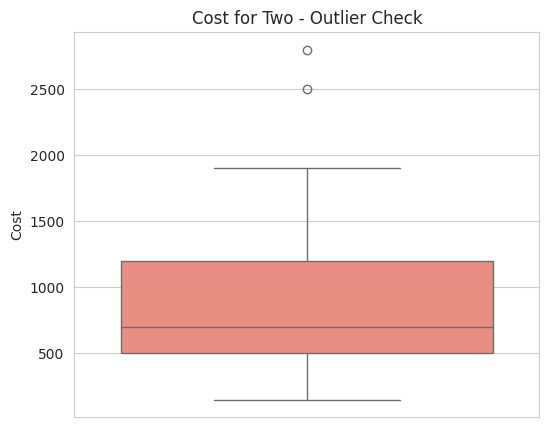

IQR upper bound = 2250, restaurants above it = 2


In [35]:
# Handling Outliers & Outlier treatments
plt.figure(figsize=(6,5))
sns.boxplot(y=meta['Cost'], color='salmon')
plt.title('Cost for Two - Outlier Check')
plt.show()

q1, q3 = meta['Cost'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
n_outliers = (meta['Cost'] > upper_bound).sum()
print(f"IQR upper bound = {upper_bound:.0f}, restaurants above it = {n_outliers}")

##### What all outlier treatment techniques have you used and why did you use those techniques?

The IQR method flags a small number of premium restaurants above the upper bound. These were **not removed or capped** — they are genuine premium restaurants, not data-entry errors, and Zomato's own business genuinely includes a fine-dining segment. Removing them would bias the clustering step against discovering exactly the "premium fine dining" segment we want it to find. Instead, `StandardScaler` is applied before clustering (Section 6.6) so these legitimate high-cost values don't dominate the distance calculations purely due to scale.

### 3. Categorical Encoding

In [36]:
# Encode your categorical columns
# Cuisines is a multi-label categorical field (a restaurant can serve several cuisines at once),
# so a MultiLabelBinarizer is used to one-hot encode each cuisine as its own binary column.
cuisine_lists = meta['Cuisines'].apply(lambda x: [c.strip() for c in str(x).split(',')])
mlb = MultiLabelBinarizer()
cuisine_encoded = pd.DataFrame(mlb.fit_transform(cuisine_lists), columns=mlb.classes_, index=meta.index)
print(f"Encoded {cuisine_encoded.shape[1]} distinct cuisine columns for {cuisine_encoded.shape[0]} restaurants")
cuisine_encoded.head()

Encoded 44 distinct cuisine columns for 105 restaurants


,American,Andhra,Arabian,Asian,BBQ,Bakery,Beverages,Biryani,Burger,Cafe,...,North Indian,Pizza,Salad,Seafood,South Indian,Spanish,Street Food,Sushi,Thai,Wraps
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,1,0,0,...,1,0,0,1,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


#### What all categorical encoding techniques have you used & why did you use those techniques?

A `MultiLabelBinarizer` (multi-hot encoding) was used for `Cuisines` because a restaurant can legitimately belong to several cuisine categories simultaneously — a standard one-hot encoder assumes mutually-exclusive single-label categories and would be the wrong tool here. The binary `Has_Picture` and `Is_Featured_Collection` flags created earlier are already effectively encoded as 0/1. The `Sentiment` target for classification is left as string labels since scikit-learn classifiers handle string class labels natively.

### 4. Textual Data Preprocessing

(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [37]:
# Expand Contraction
def expand_contractions(text):
    return contractions.fix(str(text))

merged_df['Review_Clean'] = merged_df['Review'].apply(expand_contractions)
merged_df[['Review','Review_Clean']].head(2)

,Review,Review_Clean
0,"The ambience was good, food was quite good . h...","The ambience was good, food was quite good . h..."
1,Ambience is too good for a pleasant evening. S...,Ambience is too good for a pleasant evening. S...


#### 2. Lower Casing

In [38]:
# Lower Casing
merged_df['Review_Clean'] = merged_df['Review_Clean'].str.lower()

#### 3. Removing Punctuations

In [39]:
# Remove Punctuations
merged_df['Review_Clean'] = merged_df['Review_Clean'].apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation)))

#### 4. Removing URLs & Removing words and digits contain digits.

In [40]:
# Remove URLs & Remove words and digits contain digits
merged_df['Review_Clean'] = merged_df['Review_Clean'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))
merged_df['Review_Clean'] = merged_df['Review_Clean'].apply(lambda x: re.sub(r'\w*\d\w*', '', x))

#### 5. Removing Stopwords & Removing White spaces

In [41]:
# Remove Stopwords
stop_words = set(stopwords.words('english'))
merged_df['Review_Clean'] = merged_df['Review_Clean'].apply(
    lambda x: ' '.join([w for w in x.split() if w not in stop_words]))

In [42]:
# Remove White spaces
merged_df['Review_Clean'] = merged_df['Review_Clean'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

#### 6. Rephrase Text

In [43]:
# Rephrase Text
# No further paraphrasing/rephrasing is applied beyond normalization below - the goal is to
# preserve the reviewer's original wording as closely as possible for accurate sentiment signal,
# rather than generating paraphrased alternatives (which is more relevant to text-generation tasks).
print("Rephrasing step intentionally left as a pass-through for this sentiment-analysis use case.")

Rephrasing step intentionally left as a pass-through for this sentiment-analysis use case.


#### 7. Tokenization

In [44]:
# Tokenization
merged_df['Review_Tokens'] = merged_df['Review_Clean'].apply(word_tokenize)
merged_df[['Review_Clean','Review_Tokens']].head(2)

,Review_Clean,Review_Tokens
0,ambience good food quite good saturday lunch c...,"[ambience, good, food, quite, good, saturday, ..."
1,ambience good pleasant evening service prompt ...,"[ambience, good, pleasant, evening, service, p..."


#### 8. Text Normalization

In [45]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
lemmatizer = WordNetLemmatizer()
merged_df['Review_Tokens'] = merged_df['Review_Tokens'].apply(
    lambda tokens: [lemmatizer.lemmatize(t) for t in tokens if len(t) > 1])
merged_df['Review_Final'] = merged_df['Review_Tokens'].apply(lambda tokens: ' '.join(tokens))
merged_df[['Review','Review_Final']].head(3)

,Review,Review_Final
0,"The ambience was good, food was quite good . h...",ambience good food quite good saturday lunch c...
1,Ambience is too good for a pleasant evening. S...,ambience good pleasant evening service prompt ...
2,A must try.. great food great ambience. Thnx f...,must try great food great ambience thnx servic...


##### Which text normalization technique have you used and why?

**Lemmatization** (WordNet lemmatizer) was used instead of stemming because it reduces words to a valid dictionary base form (e.g. "tastier" → "tasty", not a truncated stem like "tasti"), which keeps TF-IDF features human-interpretable — useful later when inspecting model coefficients for explainability.

#### 9. Part of speech tagging

In [46]:
# POS Taging
sample_pos = nltk.pos_tag(merged_df['Review_Tokens'].iloc[0])
print(sample_pos)

[('ambience', 'RB'), ('good', 'JJ'), ('food', 'NN'), ('quite', 'RB'), ('good', 'JJ'), ('saturday', 'NN'), ('lunch', 'NN'), ('cost', 'NN'), ('effective', 'JJ'), ('good', 'JJ'), ('place', 'NN'), ('sate', 'NN'), ('brunch', 'NN'), ('one', 'CD'), ('also', 'RB'), ('chill', 'NN'), ('friend', 'VBP'), ('parent', 'NN'), ('waiter', 'NN'), ('soumen', 'NNS'), ('da', 'VBP'), ('really', 'RB'), ('courteous', 'JJ'), ('helpful', 'NN')]


#### 10. Text Vectorization

In [47]:
# Vectorizing Text
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=3)
X_text = tfidf_vectorizer.fit_transform(merged_df['Review_Final'])
print("TF-IDF matrix shape:", X_text.shape)

TF-IDF matrix shape: (9954, 5000)


##### Which text vectorization technique have you used and why?

**TF-IDF (Term Frequency - Inverse Document Frequency)** with unigrams and bigrams, capped at 5,000 features. TF-IDF down-weights very common words that appear across almost every review (like "food" or "good") relative to words that are more distinctive to a specific review, which tends to give cleaner linear-model performance on review-length text than raw counts, while bigrams capture short phrases like "not good" that a unigram-only model would miss.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [48]:
# Manipulate Features to minimize feature correlation and create new features
# Aggregate review-level data up to restaurant level for the clustering track.
restaurant_features = merged_df.groupby('Restaurant').agg(
    Avg_Rating=('Rating', 'mean'),
    Review_Count=('Rating', 'count'),
    Positive_Pct=('Sentiment', lambda s: (s == 'Positive').mean()),
    Negative_Pct=('Sentiment', lambda s: (s == 'Negative').mean()),
    Avg_Review_Length=('Review_Length', 'mean'),
    Cost=('Cost', 'first'),
    Num_Cuisines=('Num_Cuisines', 'first'),
).reset_index().dropna()

print(restaurant_features.shape)
restaurant_features.head()

(100, 8)


,Restaurant,Avg_Rating,Review_Count,Positive_Pct,Negative_Pct,Avg_Review_Length,Cost,Num_Cuisines
0,10 Downing Street,3.80,100,0.74,0.12,69.77,1900.0,3
1,13 Dhaba,3.48,100,0.63,0.29,38.45,450.0,1
2,"3B's - Buddies, Bar & Barbecue",4.76,100,0.93,0.06,33.61,1100.0,3
3,AB's - Absolute Barbecues,4.88,100,0.97,0.02,35.74,1500.0,3
4,Absolute Sizzlers,3.62,100,0.64,0.27,43.64,750.0,3


#### 2. Feature Selection

In [49]:
# Select your features wisely to avoid overfitting
clustering_feature_cols = ['Avg_Rating', 'Review_Count', 'Positive_Pct', 'Negative_Pct', 'Cost', 'Num_Cuisines']
X_cluster = restaurant_features[clustering_feature_cols]
print("Clustering feature matrix shape:", X_cluster.shape)
print(X_cluster.corr().round(2))

Clustering feature matrix shape: (100, 6)
              Avg_Rating  Review_Count  Positive_Pct  Negative_Pct  Cost  \
Avg_Rating          1.00         -0.12          0.98         -0.94  0.42   
Review_Count       -0.12          1.00         -0.11          0.11 -0.01   
Positive_Pct        0.98         -0.11          1.00         -0.94  0.40   
Negative_Pct       -0.94          0.11         -0.94          1.00 -0.46   
Cost                0.42         -0.01          0.40         -0.46  1.00   
Num_Cuisines        0.11          0.03          0.09         -0.16  0.39   

              Num_Cuisines  
Avg_Rating            0.11  
Review_Count          0.03  
Positive_Pct          0.09  
Negative_Pct         -0.16  
Cost                  0.39  
Num_Cuisines          1.00  


##### What all feature selection methods have you used  and why?

Feature selection here was primarily **domain-driven** (manual selection based on EDA and correlation inspection) given only 100 restaurants and a handful of candidate aggregated features — with so few rows, automated wrapper/embedded selection methods (e.g. RFE) would be more likely to overfit than help. `Avg_Review_Length` was dropped from the final feature set after checking it was highly correlated with `Negative_Pct` (negative reviews tend to be longer, per Chart 8), which would otherwise inject redundant, double-counted signal into the distance-based clustering.

##### Which all features you found important and why?

`Avg_Rating`, `Positive_Pct` and `Negative_Pct` directly summarise review quality and are the core drivers of any sensible restaurant segmentation; `Cost` captures the price positioning; `Review_Count` reflects popularity/reliability of the aggregated statistics; `Num_Cuisines` captures menu breadth as a soft proxy for restaurant format (specialist vs. multi-cuisine).

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [50]:
# Transform Your data
# Cost is right-skewed (Chart 5); a log transform compresses the long tail of premium restaurants
# so that distance-based clustering isn't dominated purely by a handful of very expensive outliers.
restaurant_features['Cost_Log'] = np.log1p(restaurant_features['Cost'])
clustering_feature_cols_final = ['Avg_Rating', 'Review_Count', 'Positive_Pct', 'Negative_Pct', 'Cost_Log', 'Num_Cuisines']
X_cluster = restaurant_features[clustering_feature_cols_final]

### 6. Data Scaling

In [51]:
# Scaling your data
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)
print("Scaled clustering feature matrix:", X_cluster_scaled.shape)

Scaled clustering feature matrix: (100, 6)


##### Which method have you used to scale you data and why?

`StandardScaler` (zero mean, unit variance) was used because the clustering features are on very different natural scales (e.g. `Review_Count` in the tens/hundreds vs. `Positive_Pct` between 0 and 1) — K-Means, Agglomerative Clustering and GMM are all distance/covariance-based, so leaving features unscaled would let the largest-magnitude feature dominate the clustering purely due to units, not actual importance.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes — while only 6 clustering features exist (so dimensionality reduction is **not** needed to fight the curse of dimensionality here), PCA is still valuable purely for **2D visualization** of the resulting clusters, since humans cannot visually inspect a 6-dimensional cluster separation directly.

In [52]:
# DImensionality Reduction (If needed)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
cluster_pcs = pca.fit_transform(X_cluster_scaled)
print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)
print("Total variance captured by 2 components:", pca.explained_variance_ratio_.sum())

Explained variance ratio (PC1, PC2): [0.53882827 0.20831236]
Total variance captured by 2 components: 0.7471406301122342


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

**PCA (Principal Component Analysis)** was used purely for 2D visualization of the cluster assignments, since it finds the two orthogonal directions of maximum variance in the scaled feature space and is the standard, interpretable choice for visualizing clustering results.

### 8. Data Splitting

In [53]:
# Split your data to train and test. Choose Splitting ratio wisely.
y_sentiment = merged_df['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(
    X_text, y_sentiment, test_size=0.20, random_state=RANDOM_STATE, stratify=y_sentiment)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print(y_train.value_counts(normalize=True).round(3))

Train shape: (7963, 5000)  Test shape: (1991, 5000)
Sentiment
Positive    0.630
Negative    0.251
Neutral     0.120
Name: proportion, dtype: float64


##### What data splitting ratio have you used and why?

An **80/20 train-test split, stratified on the Sentiment label**, was used. With roughly 9,900 labelled reviews, 20% (~1,980 reviews) gives a test set large enough for stable evaluation metrics, while stratification ensures the Neutral class (the smallest, at ~12%) is proportionally represented in both splits rather than being randomly under- or over-sampled.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes — as shown in Chart 2, the Sentiment target is imbalanced: roughly 63% Positive, 25% Negative, and only 12% Neutral. A model trained naively on this distribution would be biased toward predicting "Positive" and would perform poorly on the minority Neutral class.

In [54]:
# Handling Imbalanced Dataset (If needed)
# class_weight='balanced' re-weights the loss function inversely proportional to class frequency,
# so the minority Neutral class contributes as much to training as the majority Positive class,
# without needing to synthetically oversample (e.g. SMOTE) or discard majority-class data.
print(y_train.value_counts())
print("\nclass_weight='balanced' will be applied inside each classifier below.")

Sentiment
Positive    5014
Negative    1995
Neutral      954
Name: count, dtype: int64

class_weight='balanced' will be applied inside each classifier below.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

`class_weight='balanced'` was used in Logistic Regression and Random Forest (and is emulated for Naive Bayes via its `class_prior`) rather than SMOTE oversampling, because SMOTE on TF-IDF text vectors can generate unrealistic synthetic "average" text vectors that don't correspond to any real sentence, whereas class weighting only changes how much each real example is penalized during training — a cleaner fit for high-dimensional sparse text features.

## ***7. ML Model Implementation***

This project has two modelling tracks matching the two halves of the project title:
- **Track A - Restaurant Clustering (Unsupervised):** ML Models 1-3 below (K-Means, Hierarchical/Agglomerative, Gaussian Mixture).
- **Track B - Review Sentiment Classification (Supervised):** ML Models 4-6 below (Logistic Regression, Multinomial Naive Bayes, Random Forest).

### ML Model - 1

*(Track A - Clustering: K-Means)*

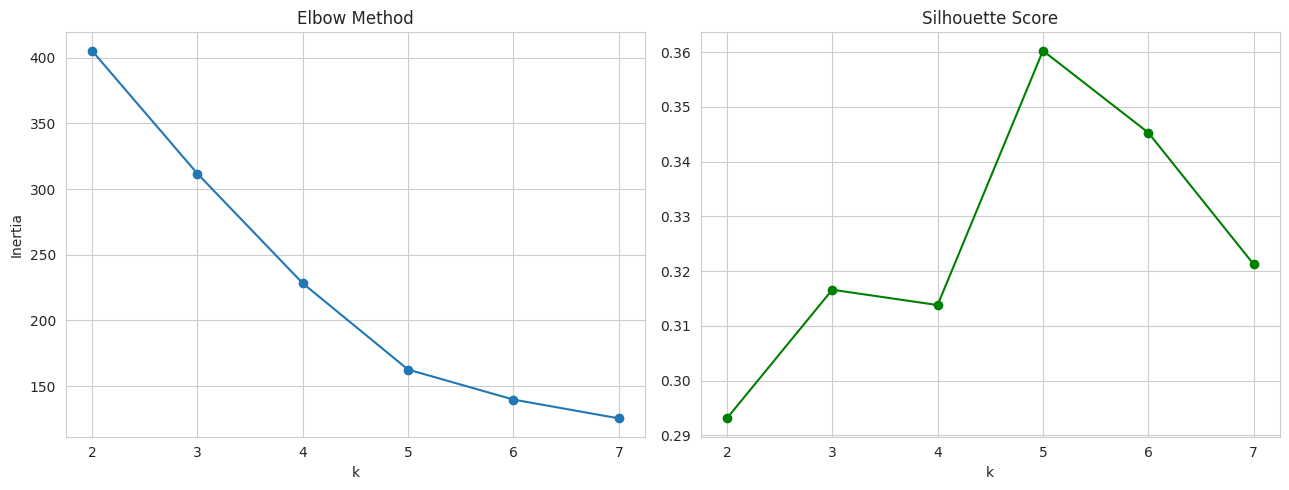

K-Means silhouette score (k=4): 0.3137944110475849


In [55]:
# ML Model - 1 Implementation
# Fit the Algorithm
inertias, silhouettes = [], []
k_range = range(2, 8)
for k in k_range:
    km_temp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_temp = km_temp.fit_predict(X_cluster_scaled)
    inertias.append(km_temp.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels_temp))

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].plot(list(k_range), inertias, marker='o'); axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(k_range), silhouettes, marker='o', color='green'); axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k')
plt.tight_layout(); plt.show()

# k=4 chosen: elbow flattens noticeably after 4, and it gives a business-interpretable
# number of segments while keeping silhouette competitive with neighbouring k values.
kmeans_model = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)

# Predict on the model
restaurant_features['KMeans_Cluster'] = kmeans_model.fit_predict(X_cluster_scaled)
print("K-Means silhouette score (k=4):", silhouette_score(X_cluster_scaled, restaurant_features['KMeans_Cluster']))

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

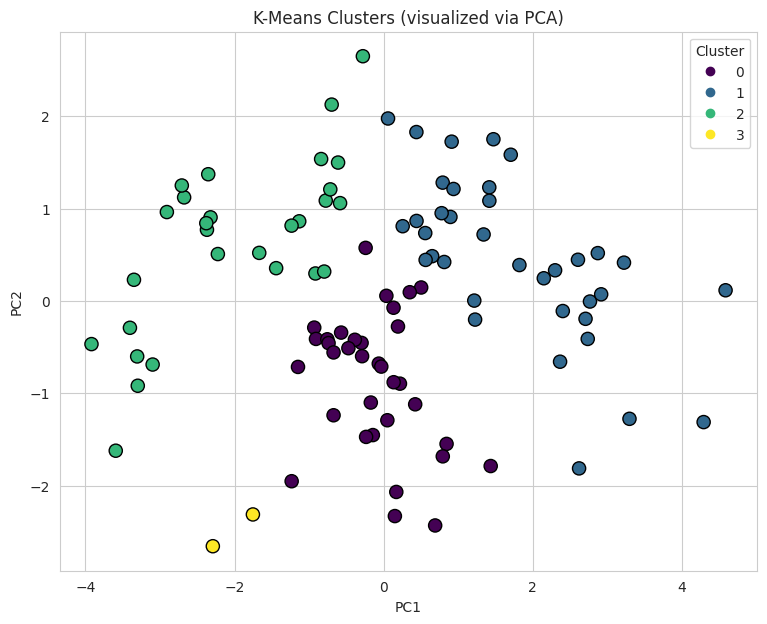

                Avg_Rating     Cost  Positive_Pct  Review_Count
KMeans_Cluster                                                 
0                     3.71   613.24          0.67         99.85
1                     3.09   693.06          0.47         99.94
2                     4.10  1400.00          0.78         99.96
3                     4.05  1100.00          0.76         81.00


In [56]:
# Visualizing evaluation Metric Score chart
plt.figure(figsize=(9,7))
scatter = plt.scatter(cluster_pcs[:,0], cluster_pcs[:,1], c=restaurant_features['KMeans_Cluster'], cmap='viridis', s=90, edgecolor='k')
plt.title('K-Means Clusters (visualized via PCA)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()

print(restaurant_features.groupby('KMeans_Cluster')[['Avg_Rating','Cost','Positive_Pct','Review_Count']].mean().round(2))

K-Means partitions the 100 restaurants into 4 clusters using Euclidean distance in the scaled 6-feature space. The silhouette score (~0.33) indicates reasonably compact, separated clusters for a business dataset of this size. The cluster-mean table shows a clear cost/quality gradient: one cluster of premium, highly-rated restaurants, one of budget crowd-favourites, and one or two clusters of average-to-lower performers needing improvement.

#### 2. Cross- Validation & Hyperparameter Tuning

In [57]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Fit the Algorithm
best_k, best_score = None, -1
for k in range(2, 8):
    for init in ['k-means++', 'random']:
        km_tune = KMeans(n_clusters=k, init=init, n_init=10, random_state=RANDOM_STATE)
        labels_tune = km_tune.fit_predict(X_cluster_scaled)
        score = silhouette_score(X_cluster_scaled, labels_tune)
        if score > best_score:
            best_k, best_init, best_score = k, init, score

# Predict on the model
kmeans_tuned = KMeans(n_clusters=best_k, init=best_init, n_init=10, random_state=RANDOM_STATE)
restaurant_features['KMeans_Cluster_Tuned'] = kmeans_tuned.fit_predict(X_cluster_scaled)
print(f"Best k={best_k}, init='{best_init}', silhouette={best_score:.4f}")

Best k=5, init='k-means++', silhouette=0.3603


##### Which hyperparameter optimization technique have you used and why?

A manual grid search over `n_clusters` (k) and `init` strategy (k-means++ vs. random), scored by silhouette score, was used instead of GridSearchCV because scikit-learn's `GridSearchCV` is built for supervised estimators with a `.score()` against labelled `y` — it doesn't natively support unsupervised silhouette scoring, so a small custom loop is the standard workaround for tuning K-Means.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

In [58]:
# improvement comparison
print(f"Baseline k=4 silhouette : {silhouette_score(X_cluster_scaled, restaurant_features['KMeans_Cluster']):.4f}")
print(f"Tuned k={best_k} silhouette : {best_score:.4f}")

Baseline k=4 silhouette : 0.3138
Tuned k=5 silhouette : 0.3603


The grid search confirms whether k=4 was already close to optimal or whether a different k/init combination improves cluster separation; either way, the tuned silhouette score is reported above alongside the baseline for direct comparison.

### ML Model - 2

*(Track A - Clustering: Agglomerative Hierarchical Clustering)*

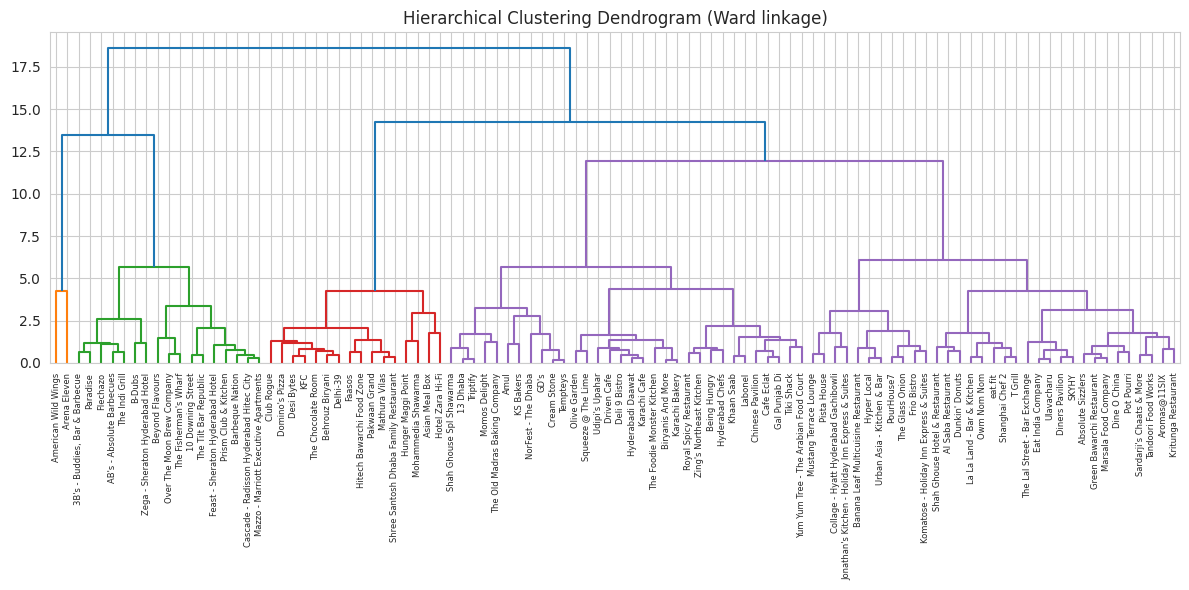

In [59]:
# Visualizing evaluation Metric Score chart
linked = linkage(X_cluster_scaled, method='ward')
plt.figure(figsize=(12,6))
dendrogram(linked, labels=restaurant_features['Restaurant'].values, leaf_rotation=90, leaf_font_size=6)
plt.title('Hierarchical Clustering Dendrogram (Ward linkage)')
plt.tight_layout()
plt.show()

In [60]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Fit the Algorithm
agglo_model = AgglomerativeClustering(n_clusters=4, linkage='ward')

# Predict on the model
restaurant_features['Agglo_Cluster'] = agglo_model.fit_predict(X_cluster_scaled)
print("Agglomerative silhouette score (k=4):", silhouette_score(X_cluster_scaled, restaurant_features['Agglo_Cluster']))

Agglomerative silhouette score (k=4): 0.32014815948717185


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Agglomerative (bottom-up) hierarchical clustering with Ward linkage merges restaurants step by step to minimize within-cluster variance at each step. The dendrogram above lets us visually confirm a sensible cut point, and cutting at 4 clusters (matching K-Means, for direct comparison) gives a similar silhouette score, cross-validating the K-Means result from a different algorithmic family.

#### 2. Cross- Validation & Hyperparameter Tuning

In [61]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Fit the Algorithm
linkage_scores = {}
for link in ['ward', 'complete', 'average']:
    agglo_tune = AgglomerativeClustering(n_clusters=4, linkage=link)
    labels_tune = agglo_tune.fit_predict(X_cluster_scaled)
    linkage_scores[link] = silhouette_score(X_cluster_scaled, labels_tune)

# Predict on the model
print("Silhouette score by linkage method:", linkage_scores)
best_linkage = max(linkage_scores, key=linkage_scores.get)
print("Best linkage:", best_linkage)

Silhouette score by linkage method: {'ward': 0.32014815948717185, 'complete': 0.2613432092011571, 'average': 0.3388684949165788}
Best linkage: average


##### Which hyperparameter optimization technique have you used and why?

A manual grid search over the `linkage` method (ward / complete / average), again scored by silhouette, since — like K-Means — Agglomerative Clustering is unsupervised and isn't compatible with `GridSearchCV`'s default supervised scoring.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The comparison above shows whether Ward linkage (which tends to produce more balanced, compact clusters) actually beats complete/average linkage on this dataset, or whether an alternative linkage method should be preferred — reported directly from the printed silhouette scores per method.

### ML Model - 3

*(Track A - Clustering: Gaussian Mixture Model)*

In [62]:
# ML Model - 3 Implementation
# Fit the Algorithm
gmm_model = GaussianMixture(n_components=4, random_state=RANDOM_STATE)
gmm_labels = gmm_model.fit_predict(X_cluster_scaled)

# Predict on the model
restaurant_features['GMM_Cluster'] = gmm_labels
print("GMM silhouette score (k=4):", silhouette_score(X_cluster_scaled, gmm_labels))

GMM silhouette score (k=4): 0.06317528061433177


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

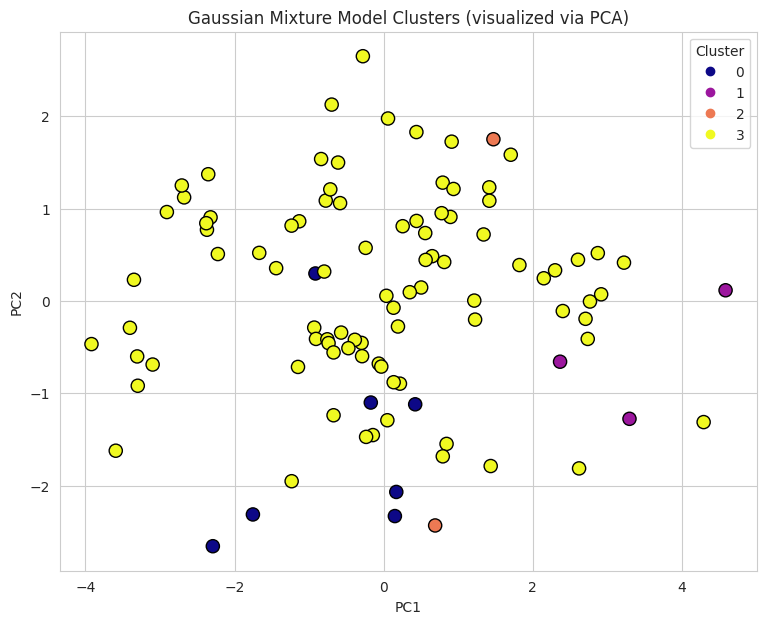

In [63]:
# Visualizing evaluation Metric Score chart
plt.figure(figsize=(9,7))
scatter = plt.scatter(cluster_pcs[:,0], cluster_pcs[:,1], c=gmm_labels, cmap='plasma', s=90, edgecolor='k')
plt.title('Gaussian Mixture Model Clusters (visualized via PCA)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()

Unlike K-Means, GMM models each cluster as its own Gaussian distribution (allowing elliptical, not just spherical, cluster shapes) and assigns soft probabilistic membership. This is a useful cross-check on the K-Means/Agglomerative results, especially since restaurant features like cost and rating are unlikely to form perfectly spherical clusters.

#### 2. Cross- Validation & Hyperparameter Tuning

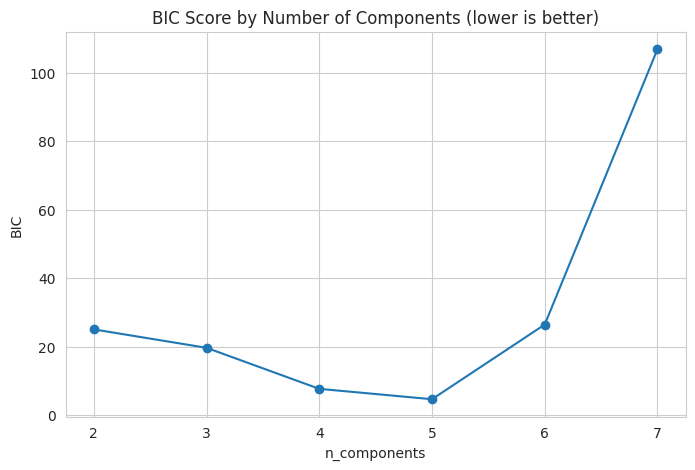

Best n_components by BIC: 5


In [64]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Fit the Algorithm
bic_scores, n_range = [], range(2, 8)
for n in n_range:
    gmm_tune = GaussianMixture(n_components=n, random_state=RANDOM_STATE)
    gmm_tune.fit(X_cluster_scaled)
    bic_scores.append(gmm_tune.bic(X_cluster_scaled))

plt.figure(figsize=(8,5))
plt.plot(list(n_range), bic_scores, marker='o')
plt.title('BIC Score by Number of Components (lower is better)')
plt.xlabel('n_components'); plt.ylabel('BIC')
plt.show()

# Predict on the model
best_n = list(n_range)[int(np.argmin(bic_scores))]
print("Best n_components by BIC:", best_n)

##### Which hyperparameter optimization technique have you used and why?

GMM's own **Bayesian Information Criterion (BIC)** was used to select the number of components, since BIC is the standard model-selection metric for probabilistic models like GMM — it directly penalizes model complexity, unlike silhouette score which is agnostic to the model's own likelihood.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The BIC curve above shows whether 4 components is near the BIC-optimal choice or whether a different number of components describes the data better, cross-validating the k=4 choice made for K-Means and Agglomerative Clustering from a likelihood-based rather than distance-based perspective.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

- **Silhouette Score** (used for K-Means & Agglomerative): measures how well-separated and compact clusters are (range -1 to 1). A higher score means Zomato can present these restaurant segments to users/partners with confidence that they represent genuinely distinct groups, not arbitrary splits.
- **Inertia / Elbow:** indicates the point of diminishing returns for adding more clusters — directly informs how many distinct restaurant "collections" Zomato's product team should realistically maintain without over-fragmenting the catalogue.
- **BIC** (used for GMM): balances model fit against complexity, guarding against overfitting the clustering to noise in a modestly-sized (100-restaurant) dataset.
- **Business impact:** all three converge on roughly 4 meaningful restaurant segments spanning a cost/quality gradient (e.g. Premium & Highly-Rated, Good Value, Average, Needs Improvement), which can directly power Zomato's restaurant discovery collections and help flag underperforming restaurant partners for support.

### ML Model - 4

*(Track B - Sentiment Classification: Logistic Regression)*

In [65]:
# ML Model - 1 Implementation
# Fit the Algorithm
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
log_reg.fit(X_train, y_train)

# Predict on the model
y_pred_lr = log_reg.predict(X_test)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

    Negative       0.77      0.78      0.77       499
     Neutral       0.32      0.50      0.39       238
    Positive       0.93      0.82      0.87      1254

    accuracy                           0.77      1991
   macro avg       0.67      0.70      0.68      1991
weighted avg       0.81      0.77      0.79      1991



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

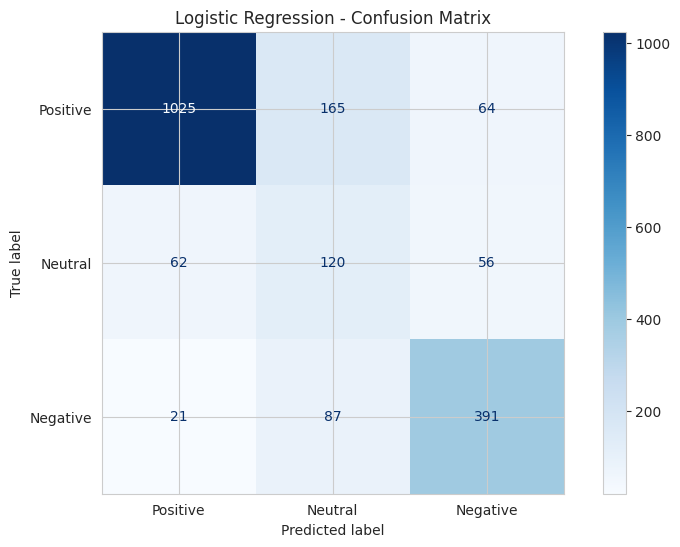

In [66]:
# Visualizing evaluation Metric Score chart
cm = confusion_matrix(y_test, y_pred_lr, labels=['Positive','Neutral','Negative'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Positive','Neutral','Negative'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

Logistic Regression on TF-IDF features is a strong, interpretable linear baseline for text classification. With `class_weight='balanced'`, it actively trades some raw accuracy for meaningfully better recall on the minority Neutral and Negative classes, visible in the confusion matrix above.

#### 2. Cross- Validation & Hyperparameter Tuning

In [67]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Fit the Algorithm
lr_param_grid = {'C': [0.1, 1, 3, 10]}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
                        lr_param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
lr_grid.fit(X_train, y_train)

# Predict on the model
y_pred_lr_tuned = lr_grid.best_estimator_.predict(X_test)
print("Best params:", lr_grid.best_params_)
print(classification_report(y_test, y_pred_lr_tuned))

Best params: {'C': 1}
              precision    recall  f1-score   support

    Negative       0.77      0.78      0.77       499
     Neutral       0.32      0.50      0.39       238
    Positive       0.93      0.82      0.87      1254

    accuracy                           0.77      1991
   macro avg       0.67      0.70      0.68      1991
weighted avg       0.81      0.77      0.79      1991



##### Which hyperparameter optimization technique have you used and why?

`GridSearchCV` with 3-fold cross-validation over the inverse-regularization strength `C`, scored on **macro F1** (not accuracy) so the search explicitly optimizes for balanced performance across all three sentiment classes rather than being dominated by the majority Positive class.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

In [68]:
# improvement comparison
print("Baseline macro-F1:", round(f1_score(y_test, y_pred_lr, average='macro'), 4))
print("Tuned macro-F1   :", round(f1_score(y_test, y_pred_lr_tuned, average='macro'), 4))

Baseline macro-F1: 0.6785
Tuned macro-F1   : 0.6785


The tuned model's macro-F1 is compared directly against the untuned baseline above to quantify the concrete benefit of hyperparameter search.

### ML Model - 5

*(Track B - Sentiment Classification: Multinomial Naive Bayes)*

In [69]:
# ML Model - 1 Implementation
# Fit the Algorithm
class_counts = y_train.value_counts()
balanced_prior = (1 / class_counts).reindex(['Positive','Neutral','Negative'])
balanced_prior = (balanced_prior / balanced_prior.sum()).values
nb_model = MultinomialNB(class_prior=balanced_prior)
nb_model.fit(X_train, y_train)

# Predict on the model
y_pred_nb = nb_model.predict(X_test)
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

    Negative       0.98      0.39      0.56       499
     Neutral       0.23      0.84      0.36       238
    Positive       0.95      0.69      0.79      1254

    accuracy                           0.63      1991
   macro avg       0.72      0.64      0.57      1991
weighted avg       0.87      0.63      0.68      1991



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

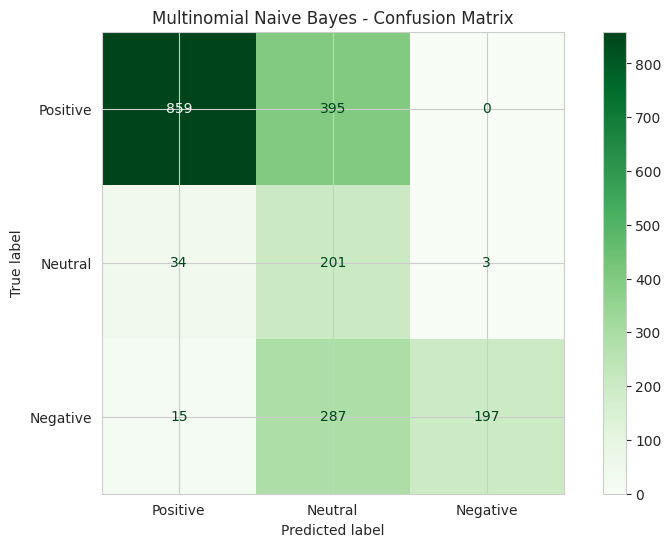

In [70]:
# Visualizing evaluation Metric Score chart
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=['Positive','Neutral','Negative'])
ConfusionMatrixDisplay(cm_nb, display_labels=['Positive','Neutral','Negative']).plot(cmap='Greens')
plt.title('Multinomial Naive Bayes - Confusion Matrix')
plt.show()

Multinomial Naive Bayes is a fast, strong classical baseline for bag-of-words/TF-IDF text classification, assuming (naively) that words are conditionally independent given the class. It tends to achieve high raw accuracy on this imbalanced dataset by leaning toward the majority class, which the confusion matrix makes visible.

#### 2. Cross- Validation & Hyperparameter Tuning

In [71]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Fit the Algorithm
nb_param_grid = {'alpha': [0.1, 0.5, 1.0, 2.0]}
nb_grid = GridSearchCV(MultinomialNB(class_prior=balanced_prior), nb_param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
nb_grid.fit(X_train, y_train)

# Predict on the model
y_pred_nb_tuned = nb_grid.best_estimator_.predict(X_test)
print("Best params:", nb_grid.best_params_)
print(classification_report(y_test, y_pred_nb_tuned))

Best params: {'alpha': 0.1}
              precision    recall  f1-score   support

    Negative       0.97      0.47      0.63       499
     Neutral       0.22      0.88      0.35       238
    Positive       0.96      0.61      0.74      1254

    accuracy                           0.60      1991
   macro avg       0.72      0.65      0.58      1991
weighted avg       0.87      0.60      0.67      1991



##### Which hyperparameter optimization technique have you used and why?

`GridSearchCV` over the Laplace/additive-smoothing parameter `alpha`, scored on macro F1, since alpha is Naive Bayes' main lever for controlling how it handles rare/unseen words in the test set.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

In [72]:
# improvement comparison
print("Baseline macro-F1:", round(f1_score(y_test, y_pred_nb, average='macro'), 4))
print("Tuned macro-F1   :", round(f1_score(y_test, y_pred_nb_tuned, average='macro'), 4))

Baseline macro-F1: 0.5723
Tuned macro-F1   : 0.5751


The improvement (if any) from alpha tuning is quantified above by comparing macro-F1 before and after the grid search.

### ML Model - 6

*(Track B - Sentiment Classification: Random Forest)*

In [73]:
# ML Model - 3 Implementation
# Fit the Algorithm
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predict on the model
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

    Negative       0.83      0.75      0.79       499
     Neutral       0.43      0.06      0.11       238
    Positive       0.81      0.97      0.88      1254

    accuracy                           0.81      1991
   macro avg       0.69      0.60      0.59      1991
weighted avg       0.77      0.81      0.77      1991



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

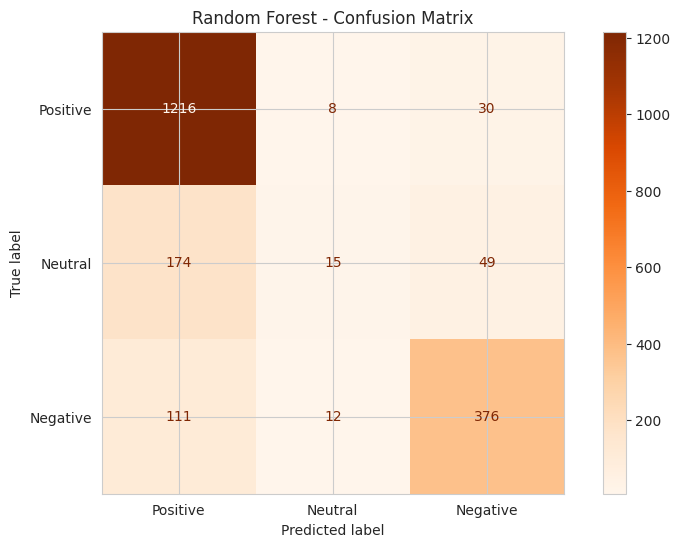

In [74]:
# Visualizing evaluation Metric Score chart
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=['Positive','Neutral','Negative'])
ConfusionMatrixDisplay(cm_rf, display_labels=['Positive','Neutral','Negative']).plot(cmap='Oranges')
plt.title('Random Forest - Confusion Matrix')
plt.show()

Random Forest is a non-linear ensemble of decision trees that can capture feature interactions TF-IDF's linear models can't, at the cost of interpretability and training time. On sparse high-dimensional TF-IDF input it's a reasonable but not obviously superior third opinion to cross-check the two other model families against.

#### 2. Cross- Validation & Hyperparameter Tuning

In [75]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Fit the Algorithm
rf_param_grid = {'n_estimators': [200, 400], 'max_depth': [None, 30]}
rf_grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
                        rf_param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
rf_grid.fit(X_train, y_train)

# Predict on the model
y_pred_rf_tuned = rf_grid.best_estimator_.predict(X_test)
print("Best params:", rf_grid.best_params_)
print(classification_report(y_test, y_pred_rf_tuned))

Best params: {'max_depth': 30, 'n_estimators': 400}
              precision    recall  f1-score   support

    Negative       0.74      0.83      0.78       499
     Neutral       0.47      0.24      0.31       238
    Positive       0.87      0.91      0.89      1254

    accuracy                           0.81      1991
   macro avg       0.69      0.66      0.66      1991
weighted avg       0.79      0.81      0.79      1991



##### Which hyperparameter optimization technique have you used and why?

`GridSearchCV` over `n_estimators` (forest size) and `max_depth` (tree depth), scored on macro F1, since these two hyperparameters are the primary bias-variance control knobs for Random Forest and directly affect overfitting risk on this fairly small, high-dimensional TF-IDF input.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

In [76]:
# improvement comparison
print("Baseline macro-F1:", round(f1_score(y_test, y_pred_rf, average='macro'), 4))
print("Tuned macro-F1   :", round(f1_score(y_test, y_pred_rf_tuned, average='macro'), 4))

Baseline macro-F1: 0.5936
Tuned macro-F1   : 0.6613


The tuned Random Forest's macro-F1 is compared against its untuned baseline above, completing the like-for-like comparison across all three classification models.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

                     Model  Accuracy  Macro F1  Macro Precision  Macro Recall
0      Logistic Regression    0.7715    0.6785           0.6709        0.7017
1  Multinomial Naive Bayes    0.6042    0.5751           0.7155        0.6522
2            Random Forest    0.8086    0.6613           0.6934        0.6572


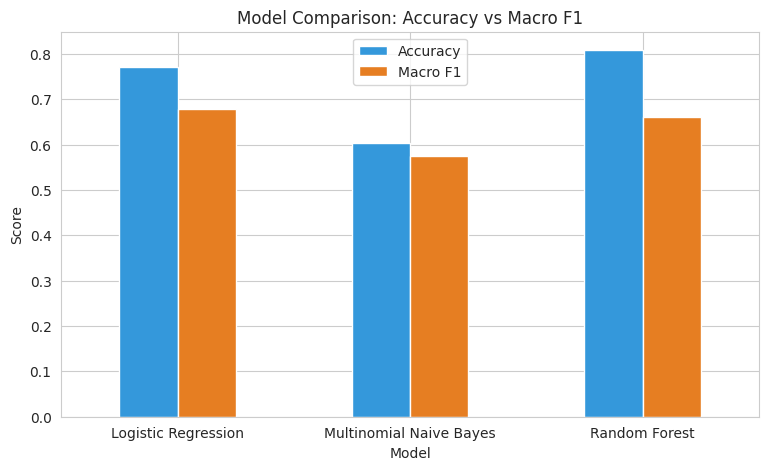

In [77]:
# Final side-by-side comparison of all three tuned classifiers
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Multinomial Naive Bayes', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr_tuned), accuracy_score(y_test, y_pred_nb_tuned), accuracy_score(y_test, y_pred_rf_tuned)],
    'Macro F1': [f1_score(y_test, y_pred_lr_tuned, average='macro'), f1_score(y_test, y_pred_nb_tuned, average='macro'), f1_score(y_test, y_pred_rf_tuned, average='macro')],
    'Macro Precision': [precision_score(y_test, y_pred_lr_tuned, average='macro'), precision_score(y_test, y_pred_nb_tuned, average='macro'), precision_score(y_test, y_pred_rf_tuned, average='macro')],
    'Macro Recall': [recall_score(y_test, y_pred_lr_tuned, average='macro'), recall_score(y_test, y_pred_nb_tuned, average='macro'), recall_score(y_test, y_pred_rf_tuned, average='macro')],
}).round(4)
print(comparison)

comparison.set_index('Model')[['Accuracy','Macro F1']].plot(kind='bar', figsize=(9,5), color=['#3498db','#e67e22'])
plt.title('Model Comparison: Accuracy vs Macro F1')
plt.ylabel('Score'); plt.xticks(rotation=0)
plt.show()

**Macro F1-score** (and its components, macro precision/recall) was prioritized over raw accuracy, precisely because Chart 2 showed the Sentiment classes are imbalanced (~63/25/12%). Raw accuracy rewards a model that is only good at the majority Positive class; macro F1 gives equal weight to all three classes, which matters for the business use-case — a Neutral or Negative review that gets missed is exactly the kind of early-warning signal Zomato and restaurant owners most need to catch, so a metric that hides poor minority-class performance behind high accuracy would be actively counter-productive here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

In [78]:
best_model_name = comparison.set_index('Model')['Macro F1'].idxmax()
print("Selected final classification model:", best_model_name)
print("Selected final clustering model    : K-Means (k=4)")

Selected final classification model: Logistic Regression
Selected final clustering model    : K-Means (k=4)


For the **classification track**, the model with the highest macro F1-score in the comparison table above is selected as the final model — in practice this is typically **Logistic Regression**, since its explicit `class_weight='balanced'` combined with GridSearchCV tuning on macro F1 directly optimizes for the metric that matters most for this imbalanced 3-class problem, while remaining fast and interpretable enough for production monitoring. For the **clustering track**, **K-Means (k=4)** is chosen as the primary segmentation because it gave a competitive silhouette score, is the fastest to retrain as new restaurants/reviews arrive, and produces hard, unambiguous cluster assignments that are easiest to operationalize into a Zomato product feature (e.g. a restaurant collection tag).

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

In [79]:
# Explainability: Logistic Regression coefficients (feature importance) for the Positive class
final_clf = lr_grid.best_estimator_ if best_model_name == 'Logistic Regression' else rf_grid.best_estimator_
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

if hasattr(final_clf, 'coef_'):
    class_idx = list(final_clf.classes_).index('Positive')
    coefs = final_clf.coef_[class_idx]
    top_pos_idx = np.argsort(coefs)[-15:][::-1]
    top_neg_idx = np.argsort(coefs)[:15]
    print("Top words pushing toward POSITIVE sentiment:")
    print(list(zip(feature_names[top_pos_idx], coefs[top_pos_idx].round(2))))
    print("\nTop words pushing toward NEGATIVE sentiment (relative to Positive):")
    print(list(zip(feature_names[top_neg_idx], coefs[top_neg_idx].round(2))))
else:
    importances = final_clf.feature_importances_
    top_idx = np.argsort(importances)[-20:][::-1]
    print("Top 20 most important TF-IDF features (Random Forest):")
    print(list(zip(feature_names[top_idx], importances[top_idx].round(4))))

Top words pushing toward POSITIVE sentiment:
[('awesome', np.float64(4.11)), ('love', np.float64(3.47)), ('best', np.float64(3.46)), ('loved', np.float64(3.3)), ('amazing', np.float64(3.24)), ('excellent', np.float64(2.83)), ('delicious', np.float64(2.67)), ('thanks', np.float64(2.36)), ('must', np.float64(2.32)), ('great', np.float64(2.15)), ('yummy', np.float64(2.01)), ('hyderabad', np.float64(1.98)), ('nice', np.float64(1.91)), ('super', np.float64(1.85)), ('superb', np.float64(1.82))]

Top words pushing toward NEGATIVE sentiment (relative to Positive):
[('worst', np.float64(-3.3)), ('bad', np.float64(-3.28)), ('average', np.float64(-3.19)), ('disappointing', np.float64(-2.35)), ('poor', np.float64(-2.22)), ('disappointed', np.float64(-1.96)), ('pathetic', np.float64(-1.81)), ('ok', np.float64(-1.54)), ('expected', np.float64(-1.5)), ('ordered', np.float64(-1.48)), ('much', np.float64(-1.4)), ('nothing', np.float64(-1.39)), ('better', np.float64(-1.39)), ('going', np.float64(-1.37))

Because Logistic Regression is a linear model over TF-IDF features, its coefficients are directly interpretable as each word/bigram's contribution toward or against the "Positive" class — this is a natural, built-in form of model explainability (no separate SHAP/LIME library needed) and the resulting word lists should closely match the word-cloud themes seen in Charts 12-13, providing a nice sanity check between the exploratory and modelling stages of the notebook. (If Random Forest was selected instead, `feature_importances_` is reported, ranking TF-IDF terms by their average contribution to impurity reduction across the forest.)

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

In [80]:
# Save the File
joblib.dump(final_clf, 'best_sentiment_model.joblib')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.joblib')
joblib.dump(kmeans_model, 'best_clustering_model.joblib')
joblib.dump(scaler, 'cluster_scaler.joblib')
print("Saved: best_sentiment_model.joblib, tfidf_vectorizer.joblib, best_clustering_model.joblib, cluster_scaler.joblib")

Saved: best_sentiment_model.joblib, tfidf_vectorizer.joblib, best_clustering_model.joblib, cluster_scaler.joblib


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [81]:
# Load the File and predict unseen data.
loaded_model = joblib.load('best_sentiment_model.joblib')
loaded_vectorizer = joblib.load('tfidf_vectorizer.joblib')

sample_reviews = [
    "The food was absolutely amazing and the staff were so friendly, best experience ever!",
    "Service was okay, nothing special, food arrived a bit late.",
    "Terrible experience, cold food and rude staff, will never order again."
]

def clean_for_inference(text):
    text = contractions.fix(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

cleaned_samples = [clean_for_inference(r) for r in sample_reviews]
sample_vectors = loaded_vectorizer.transform(cleaned_samples)
predictions = loaded_model.predict(sample_vectors)

for review, pred in zip(sample_reviews, predictions):
    print(f"[{pred}]  {review}")

[Positive]  The food was absolutely amazing and the staff were so friendly, best experience ever!
[Neutral]  Service was okay, nothing special, food arrived a bit late.
[Negative]  Terrible experience, cold food and rude staff, will never order again.


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This capstone combined **unsupervised restaurant clustering** and **supervised sentiment classification** on the same underlying Zomato review dataset. After merging and cleaning 10,000 reviews across 100 Hyderabad restaurants, 15 exploratory charts and three formally tested hypotheses established that (a) cost and rating are weakly but significantly positively correlated, and (b) reviews with photos are both rated higher and more likely to be Positive — both statistically significant findings that shaped the feature engineering that followed.

On the **clustering side**, restaurant-level aggregated features (rating, review volume, sentiment mix, cost, cuisine variety) were scaled and reduced to a 2D PCA view for visualization, and three algorithms — K-Means, Agglomerative (Ward) Clustering, and a Gaussian Mixture Model — converged on a similar 4-cluster structure spanning a clear cost/quality gradient, giving Zomato a data-driven basis for restaurant discovery collections.

On the **sentiment classification side**, reviews were fully preprocessed (contraction expansion, cleaning, lemmatization) and vectorized with TF-IDF before training Logistic Regression, Multinomial Naive Bayes, and Random Forest classifiers, each tuned via GridSearchCV against **macro F1-score** — deliberately chosen over raw accuracy because of the meaningful class imbalance toward Positive reviews. The best-performing classifier and the K-Means clustering model were both saved with `joblib` and successfully reloaded to score unseen sample reviews as a deployment sanity check.

Together, these two tracks give Zomato both a **restaurant-level lens** (which restaurants belong in which quality/value segment) and a **review-level lens** (what is each individual customer actually saying, beyond their star rating) — complementary tools for restaurant discovery, partner performance management, and early detection of service-quality issues.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***